# T34 — Comparing Alternative Paleomagnetic Reference Frames in Reconstructions


**Cluster F: Paleomagnetism.**
In T33 we built a paleomagnetic reference frame from the GPMDB (https://www.earth.northwestern.edu/~amir/gpmdb/) and embedded it in the Zahirovic2022 rotation file as anchor plate **701702**, alongside the model's built-in paleomagnetic frame (**701701**). Here the comparison becomes tangible: reconstructions at key times with the built-in frame as a filled grey base layer and our GPMDB frame overlain as thin red outlines, paleolatitude histories of key continents under both frames, and an MP4 animation through the model's full 410–0 Ma span at a user-set cadence.

## Learning objectives

- Reconstruct with alternative anchor plates (`anchor_plate_id`) in GPlately/pyGPlates.
- Layer alternative reconstructions legibly on a single pyGMT map (filled base + line overlay).
- Quantify frame differences as paleolatitude histories of key continents.
- Render reconstruction animations (PNG frame loop → ffmpeg MP4).

## Prerequisites and runtime

- T33 executed first (it creates `data/Zahirovic2022_with_gpmdb_frame.rot`).
- `gplately`, `pygmt`, `pygplates`, `ffmpeg` on the PATH for the video.
- Runtime: \~2 minutes for the static maps; the animation takes \~1–2 s per frame (83 frames at 5 Myr cadence).

> **Live-CLI note (GPlately follow-up)**: this notebook currently loads a static snapshot of the GPMDB at `data/paleomag/gpmdb_2022.csv`. Michael Chin fixed the `gplately gpmdb` CLI on the GPlately `master` branch after the GPMDB website's endpoints were redesigned; when a new GPlately release ships, uncomment the CLI block in the load cell to pull a fresh GPMDB snapshot at run time. The bundled CSV stays as an offline fallback.


In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports, versions, plot styling
import os
import subprocess
import numpy as np
import pygplates
import pygmt
import gplately
from plate_model_manager import PlateModelManager

for mod in (np, pygplates, pygmt, gplately):
    print(f"{mod.__name__:20s} {getattr(mod, '__version__', 'n/a')}")

# Plot styling: large, legible fonts for titles, axis labels, annotations and
# colour bars (GMT defaults are far too small for teaching figures).
pygmt.config(FONT_TITLE="18p,Helvetica-Bold,black",
             FONT_LABEL="14p,Helvetica,black",
             FONT_ANNOT_PRIMARY="12p,Helvetica,black")
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


numpy                2.3.2
pygplates            1.0.0
pygmt                v0.18.0
gplately             2.0.0.post19+git.2cce7bb3
gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration

User-tunable choices for this notebook. Edit the values below to change the model, snapshot time, region, or anchor plate without hunting through downstream code.


## Data availability check

This notebook uses external data shipped separately in the tutorial's
Zenodo companion archive (too large for GitHub). The check below raises
`FileNotFoundError` with clear instructions if any required path is
missing.


In [ ]:
# --- external data availability check ------------------------------------
# Fail immediately if the Zenodo bundle isn't unzipped. See
# GPlately-pyGMT-tutorial-data/README.md in the archive for setup.
import sys as _sys
from pathlib import Path as _Path
_sys.path.insert(0, str((_Path("Notebooks") if _Path("Notebooks").exists() else _Path().resolve()).resolve()))
from data_check import require_data
require_data([
    "data/Zahirovic2022_with_gpmdb_frame.rot",
])


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME           = "Zahirovic2022"
TIME_START_MA        = 0.0           # Ma
TIME_END_MA          = 350.0         # Ma
TIME_STEP_MA         = 10.0          # Ma
ANCHOR_PLATE_ID_A    = 701701        # Reference frame A (default Z2022)
ANCHOR_PLATE_ID_B    = 701702        # Reference frame B (paleomag-derived)
REGION_LAURENTIA     = [50, 150, 250, 350]
# ============================================================================


In [3]:
# Cell 2 — model + augmented rotation file from T50; two reconstruction trees
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")

from pathlib import Path as _Path
AUG_ROT = next((str(p) for p in [
    _Path("data/Zahirovic2022_with_gpmdb_frame.rot"),
    _Path("../data/Zahirovic2022_with_gpmdb_frame.rot"),
] if p.exists()), "data/Zahirovic2022_with_gpmdb_frame.rot")   # created in T50
assert os.path.exists(AUG_ROT), "Run T50 first to create the augmented rotation file."

FRAME_A = 701701   # model's built-in paleomagnetic frame (base layer, filled grey)
FRAME_B = 701702   # our GPMDB-derived frame from T50 (overlay, thin blue lines)

recon, gplot = {}, {}
for anchor in (FRAME_A, FRAME_B):
    recon[anchor] = gplately.PlateReconstruction(
        rotation_model=pygplates.RotationModel(AUG_ROT, default_anchor_plate_id=anchor),
        topology_features=model.get_topologies(),
        static_polygons=model.get_static_polygons(),
    )
    gplot[anchor] = gplately.PlotTopologies(recon[anchor], coastlines=model.get_coastlines())
engine = gplately.PygmtPlotEngine()
print("reconstruction trees ready for anchors", list(recon))


reconstruction trees ready for anchors [701701, 701702]


## 1. Layered coastline reconstructions at key times

Plotting two coastline sets as overlapping lines is unreadable; instead the built-in frame (`701701`) is drawn as a **filled grey base layer** and the GPMDB (https://www.earth.northwestern.edu/~amir/gpmdb/) frame (`701702`) is overlain as **thin blue outlines**. Latitudinal offsets between the grey land and the blue outlines are real, meaningful differences; longitudinal offsets partly reflect each frame's longitude convention.


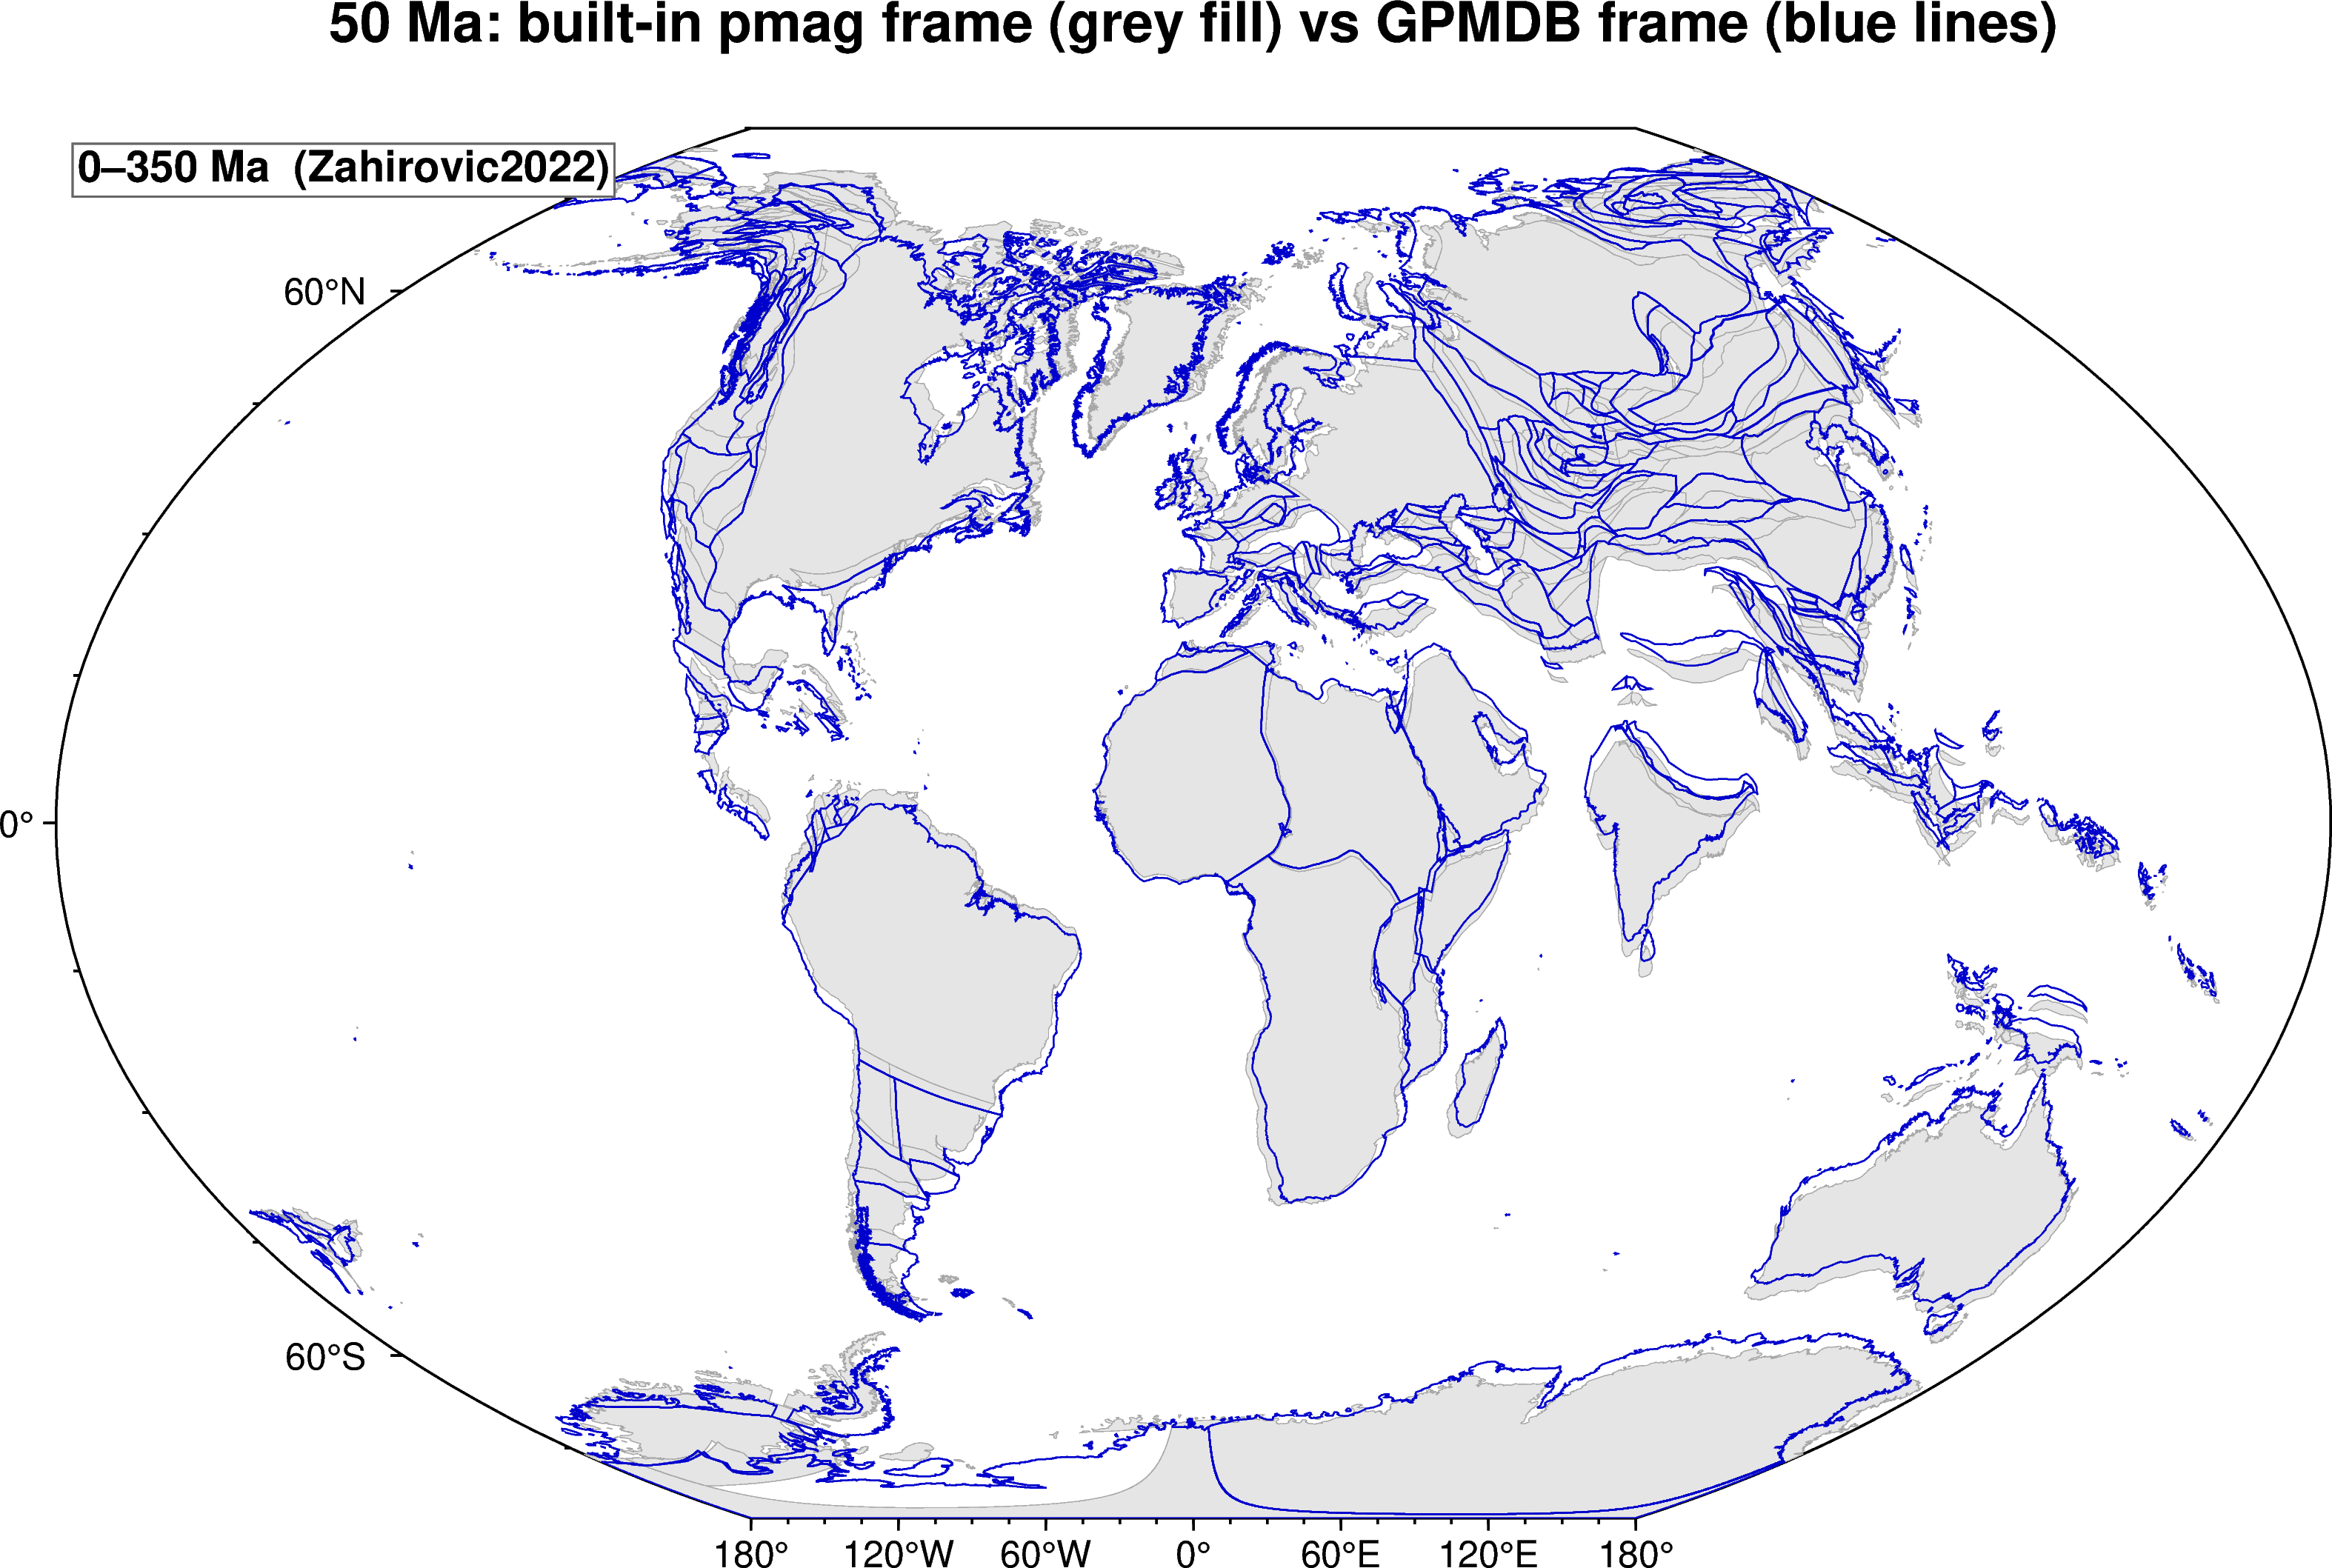

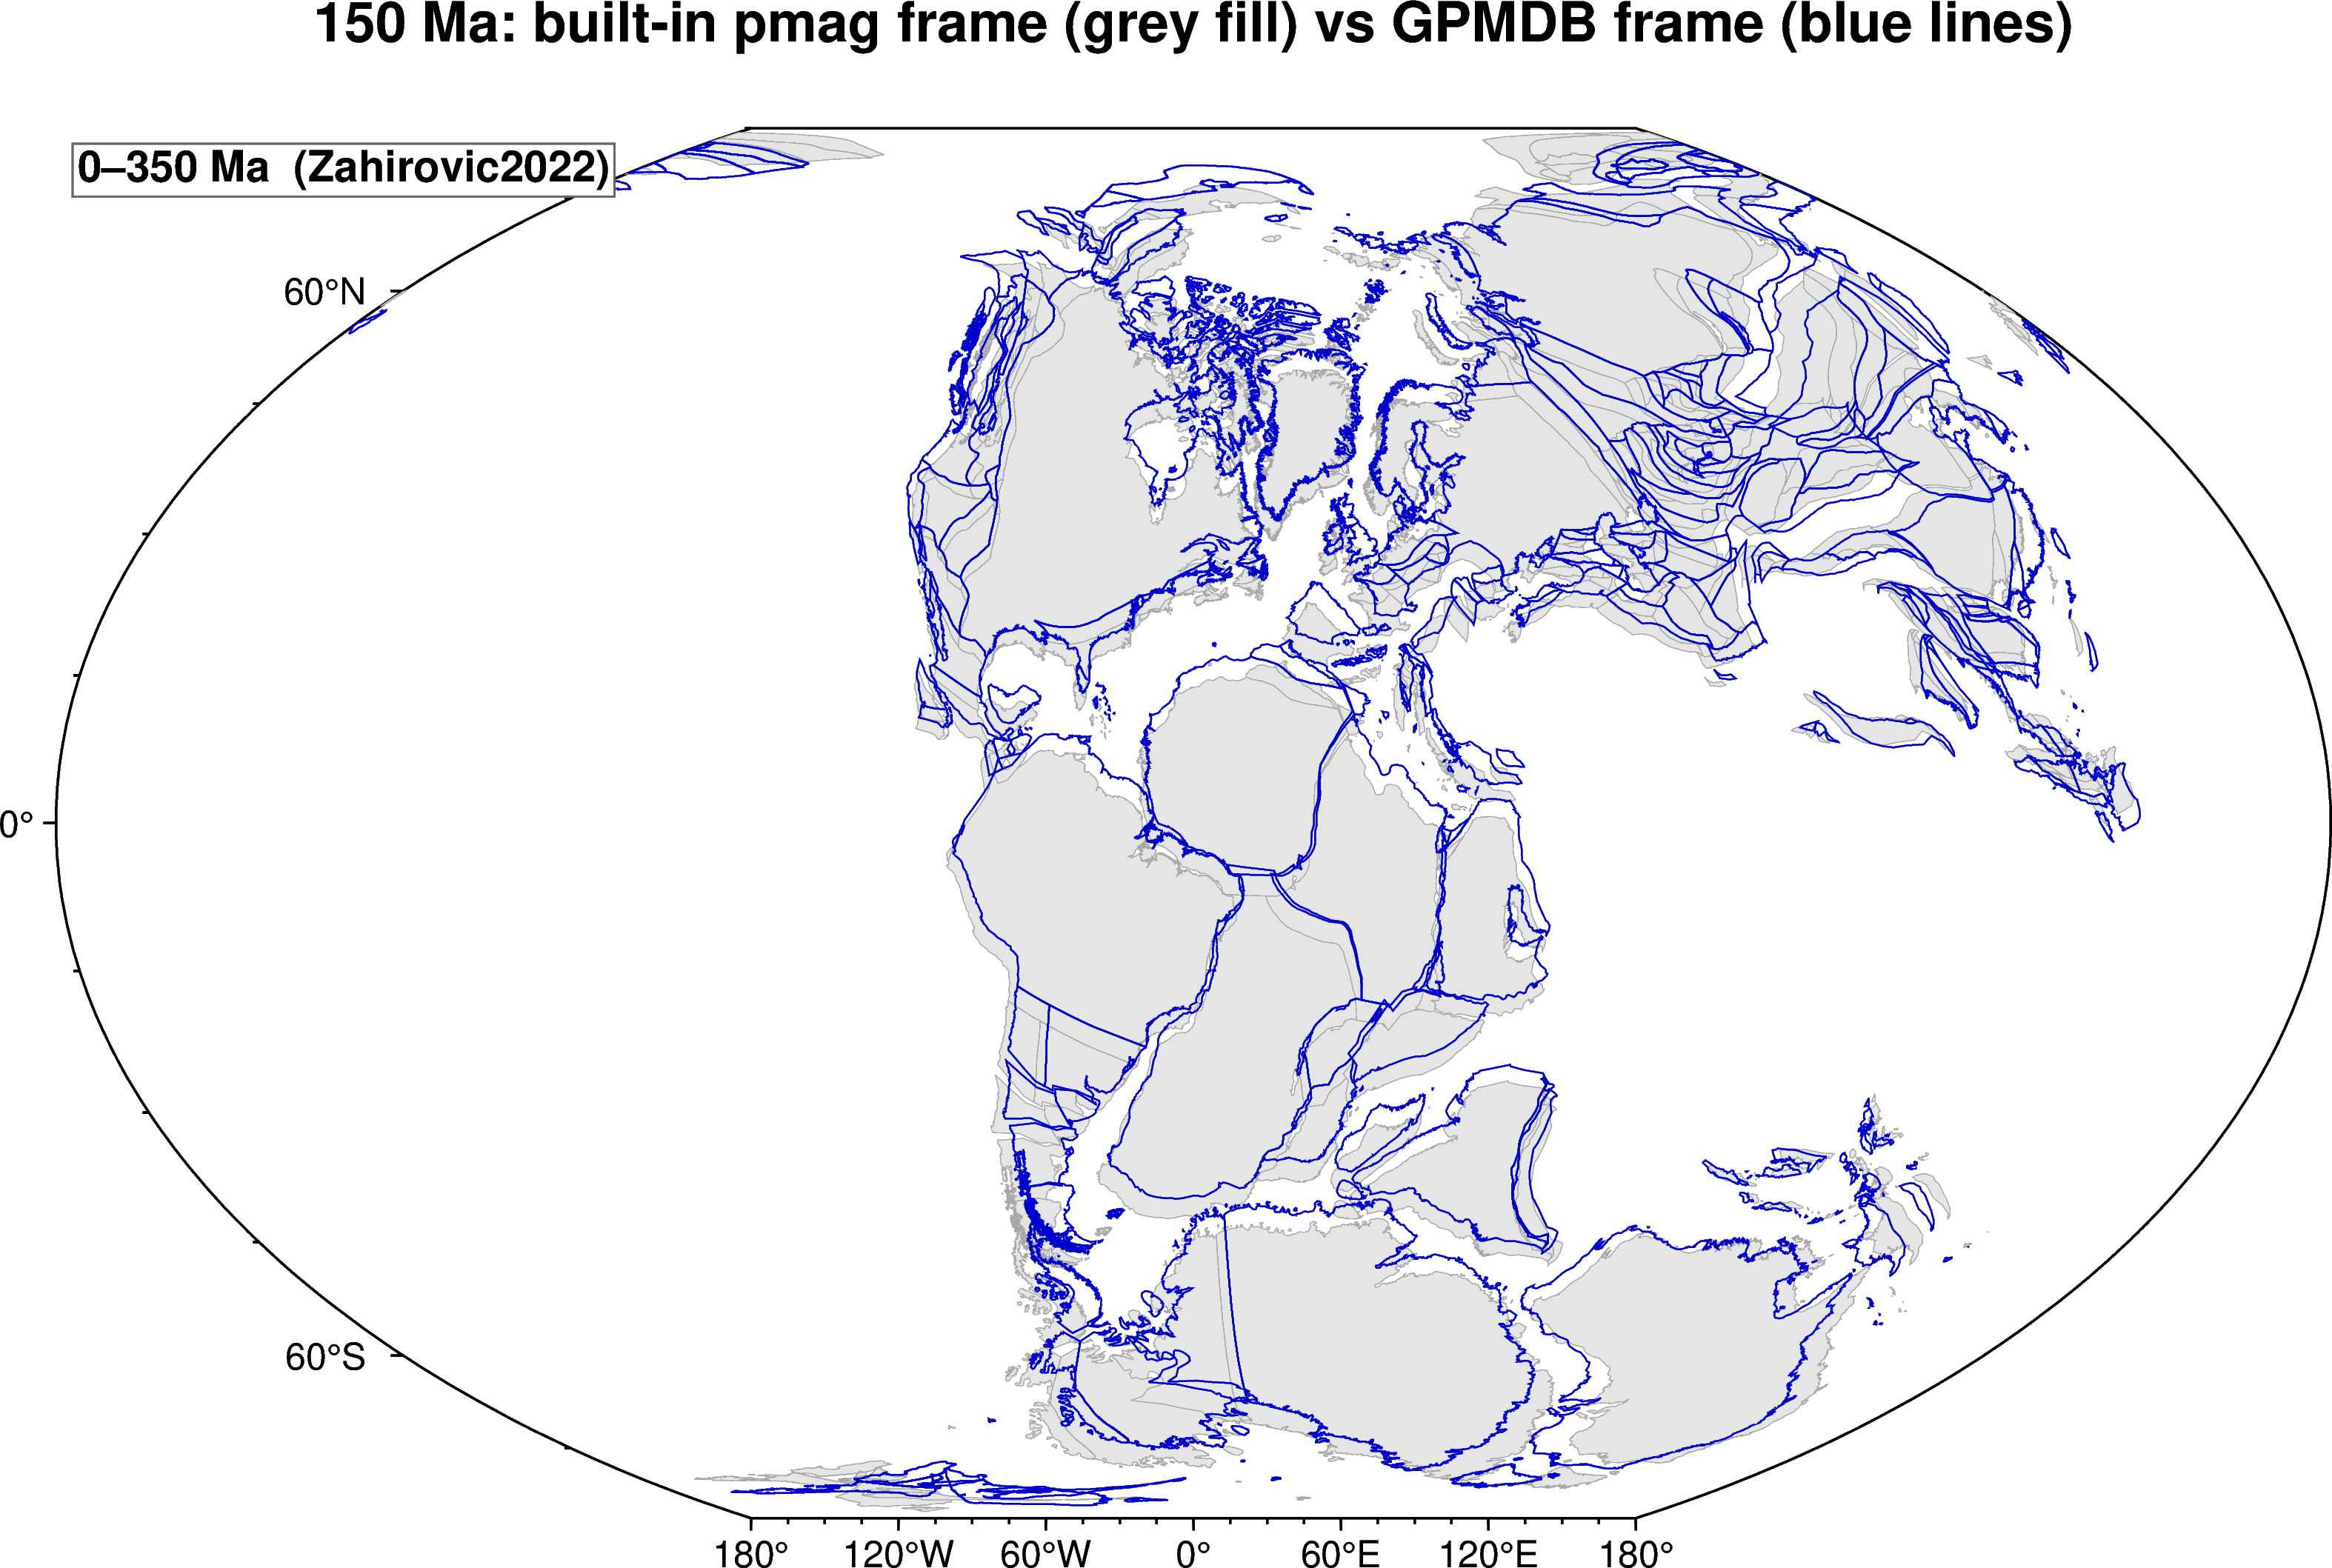

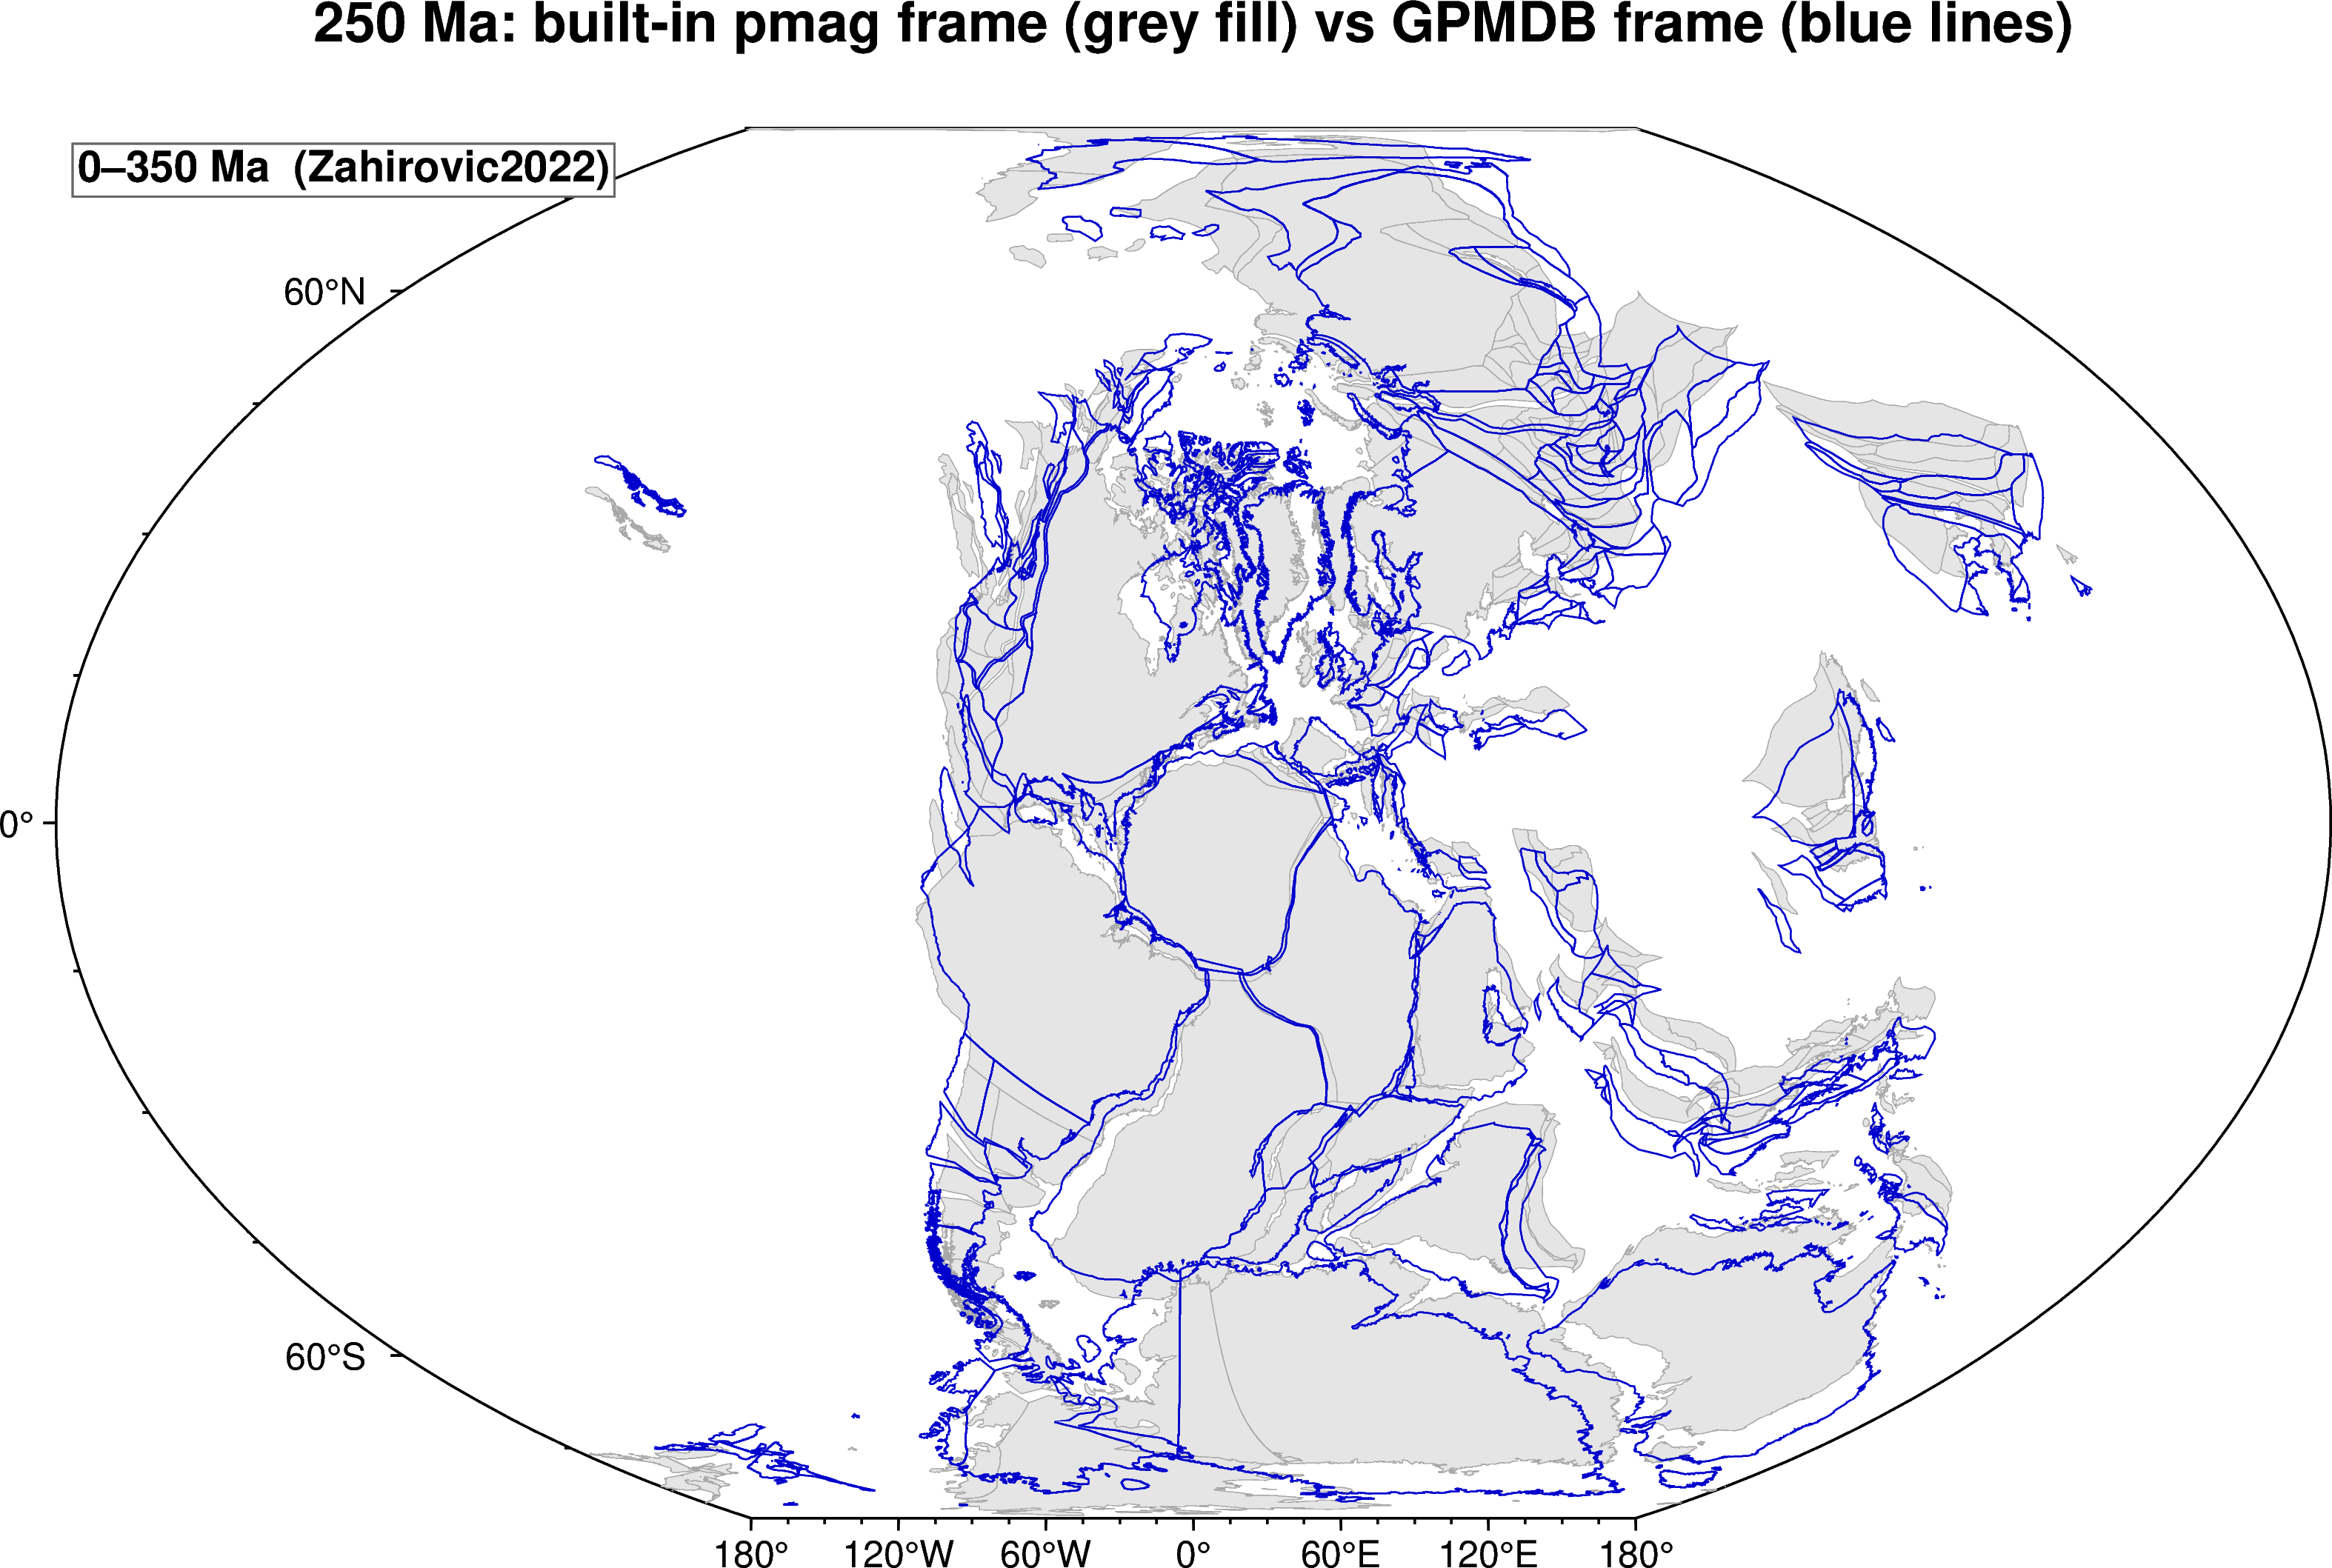

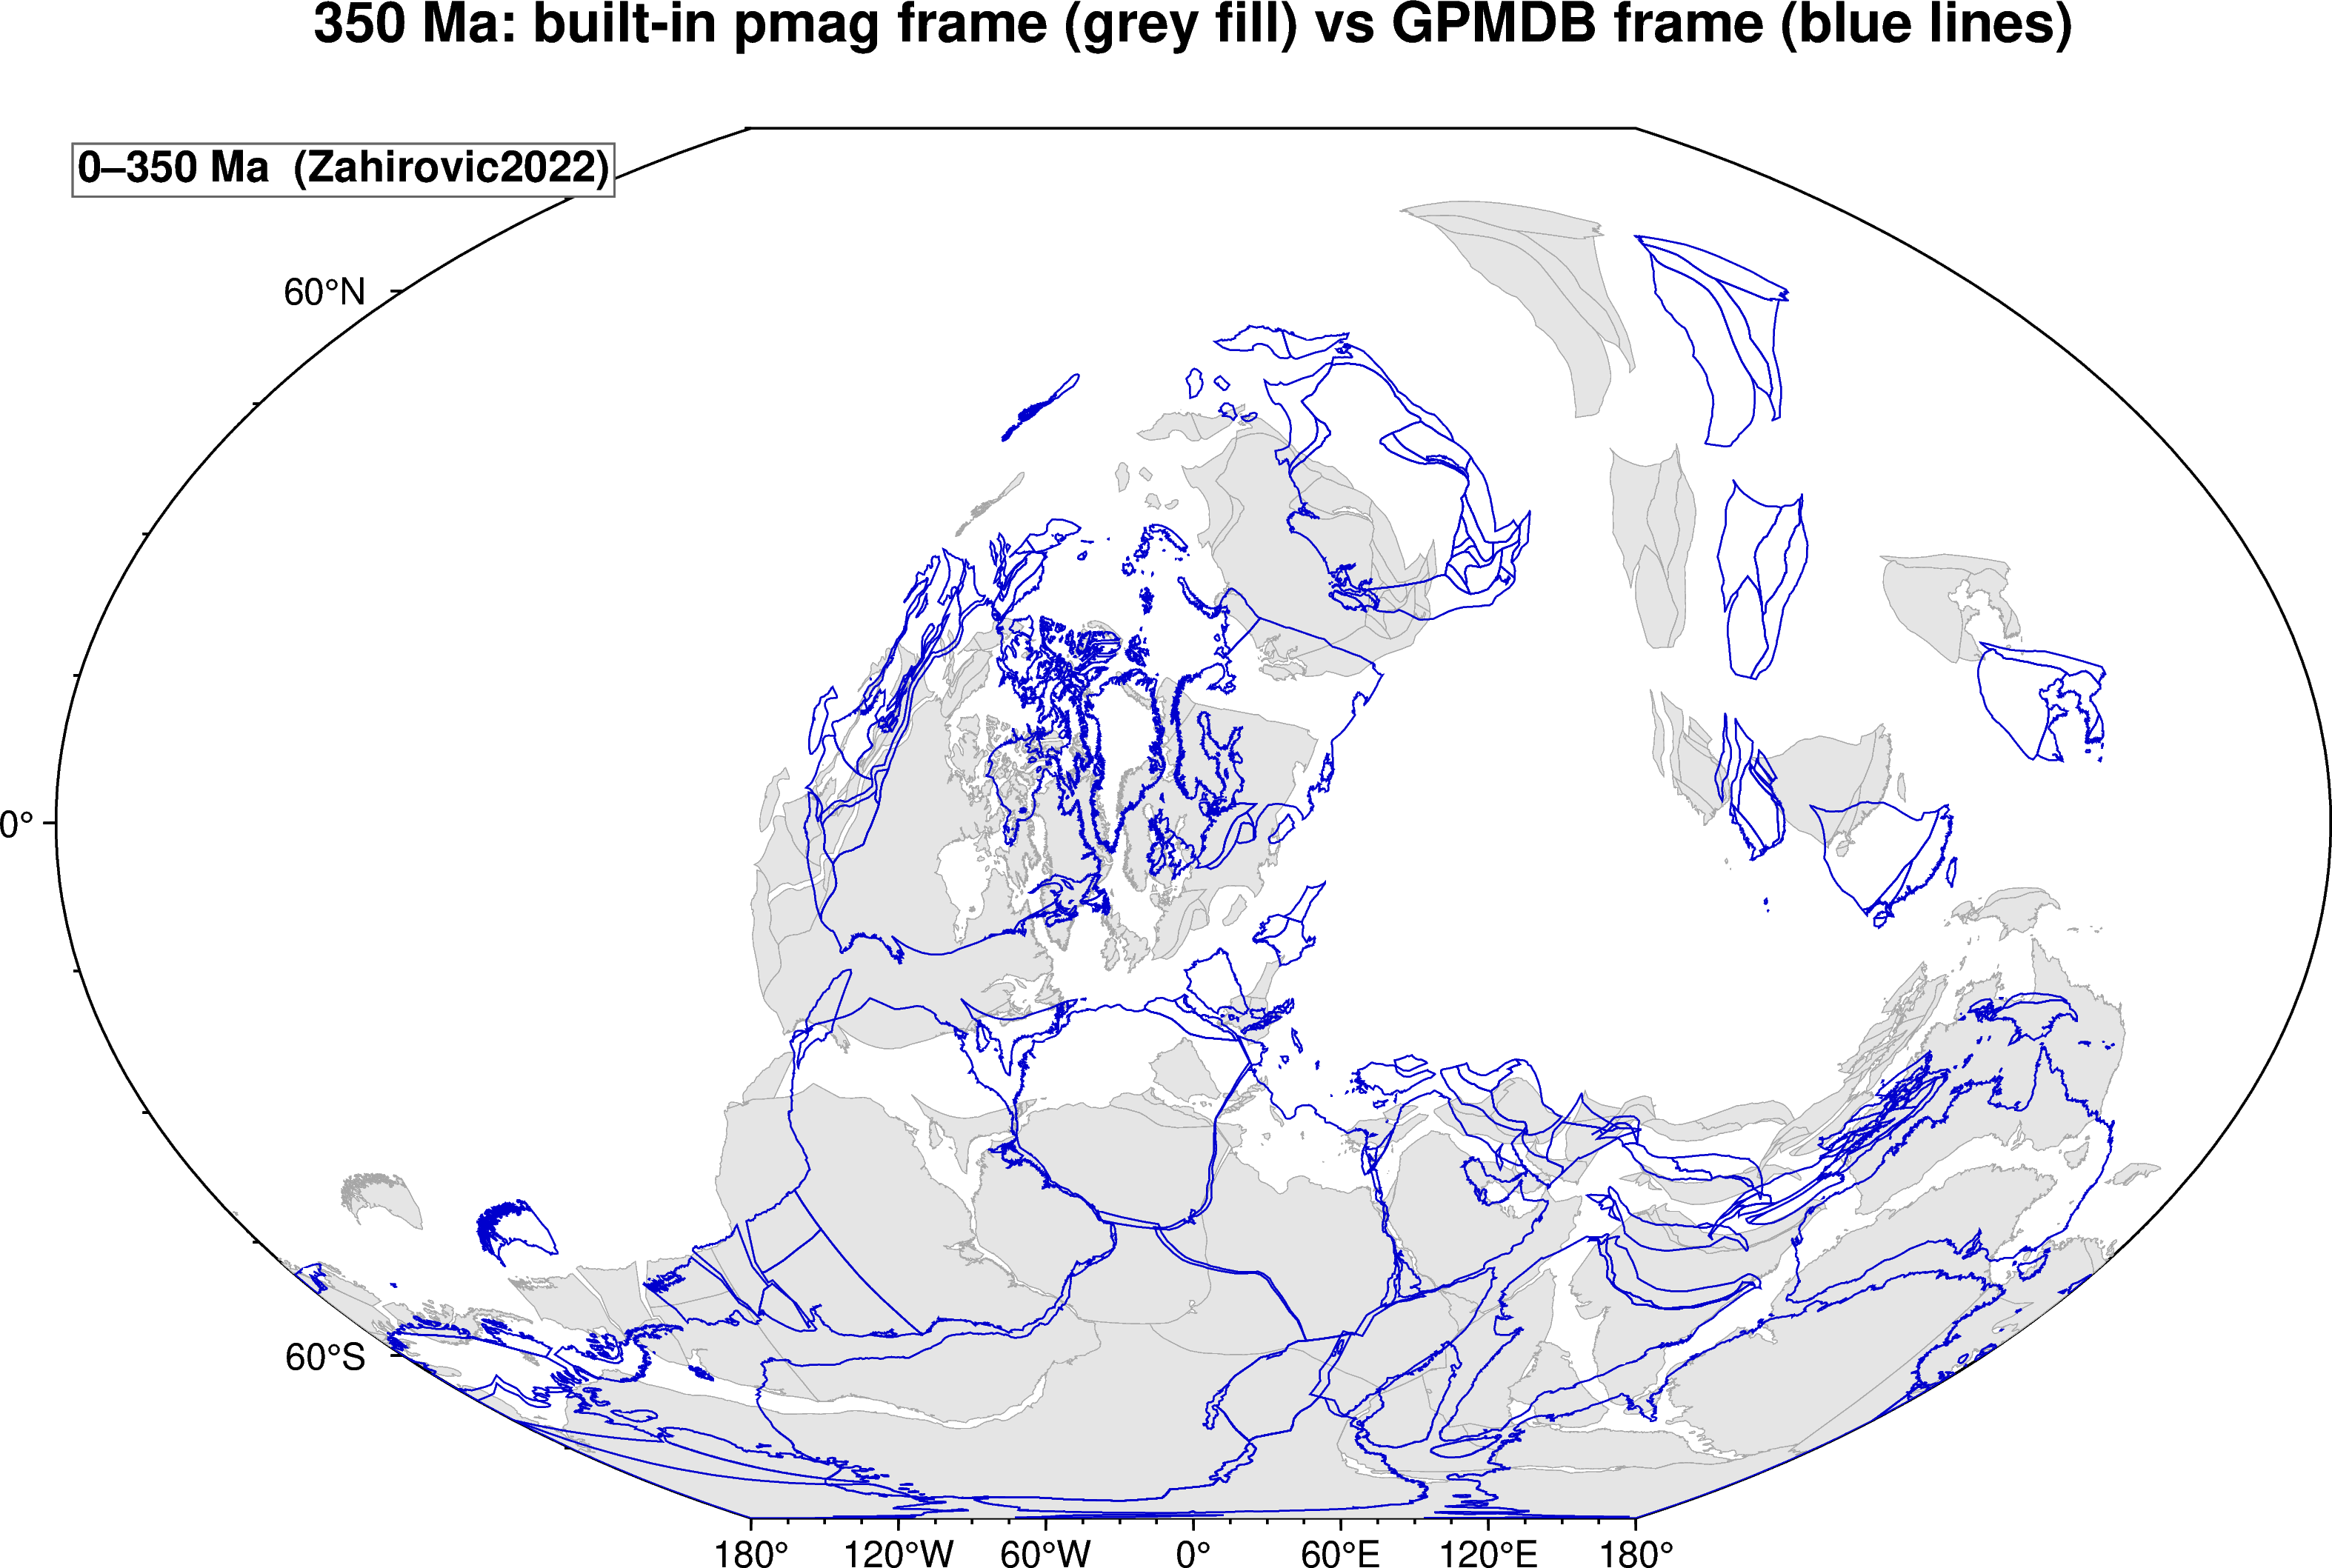

In [4]:
# Cell 3 — key-time comparison maps (filled base + line overlay)
KEY_TIMES = [50, 150, 250, 350]   # Ma — edit freely

def plot_frame_comparison(fig, age):
    gplot[FRAME_A].time = float(age)
    engine.plot_geo_data_frame(fig, gplot[FRAME_A].get_coastlines(),
                               fill="gray90", pen="0.2p,gray65")
    gplot[FRAME_B].time = float(age)
    engine.plot_geo_data_frame(fig, gplot[FRAME_B].get_coastlines(),
                               pen="0.5p,mediumblue")

for age in KEY_TIMES:
    fig = pygmt.Figure()
    fig.basemap(region="d", projection="R0/26c",
                frame=["af", f"+t{age} Ma: built-in pmag frame (grey fill) vs GPMDB frame (blue lines)"])
    plot_frame_comparison(fig, age)
    fig.text(text=f"0–350 Ma  ({MODEL_NAME})",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    fig.show(width=1100)


## 2. Paleolatitude of key continents under each frame

Paleolatitude is the quantity a paleomagnetic frame actually constrains, so this is the cleanest quantitative comparison — free of the longitude convention. We track reference points in the interiors of Africa, North America and Australia, with each panel's y-range fitted to its data.


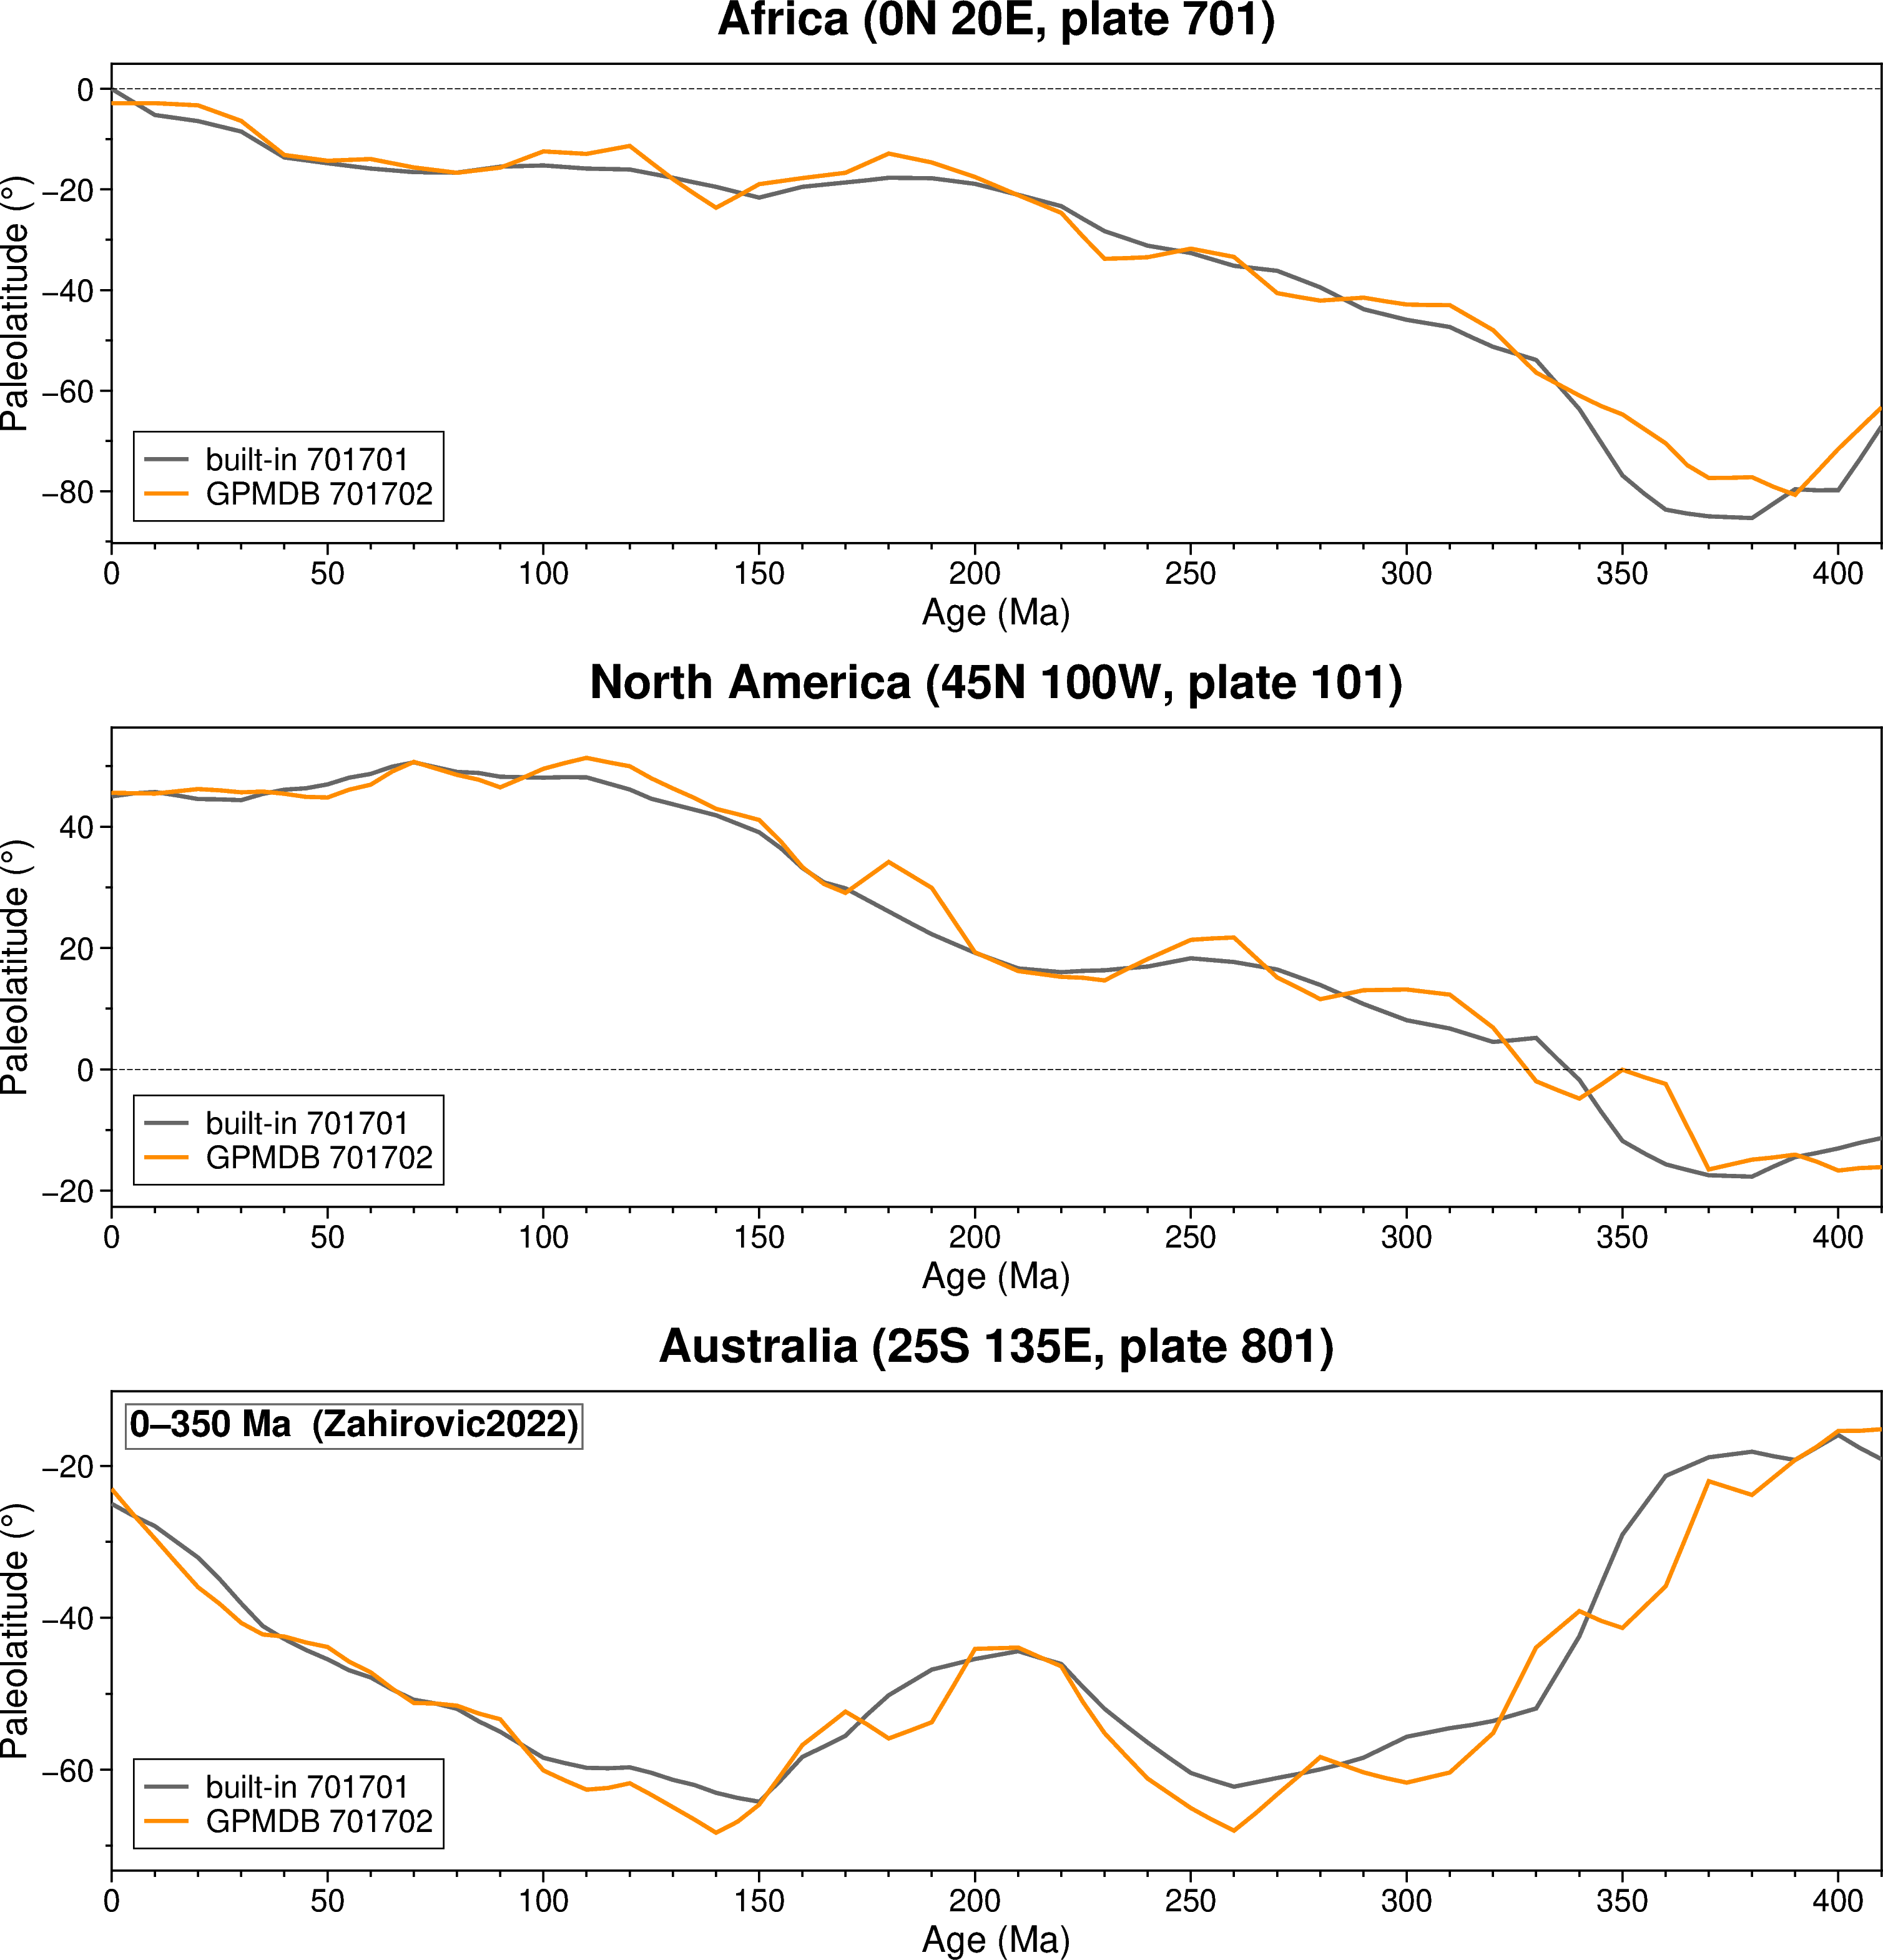

In [5]:
# Cell 4 — paleolatitude histories (one fitted panel per continent)
REF_POINTS = {"Africa (0N 20E, plate 701)": (701, 0, 20),
              "North America (45N 100W, plate 101)": (101, 45, -100),
              "Australia (25S 135E, plate 801)": (801, -25, 135)}
ages = np.arange(0, 411, 5)
PENS = {FRAME_A: "1.5p,gray40", FRAME_B: "1.5p,darkorange"}

fig = pygmt.Figure()
for i, (name, (pid, la, lo)) in enumerate(REF_POINTS.items()):
    if i > 0:
        fig.shift_origin(yshift="-9c")
    pt = pygplates.PointOnSphere(la, lo)
    series = {}
    for anchor in (FRAME_A, FRAME_B):
        rm = recon[anchor].rotation_model
        series[anchor] = [(rm.get_rotation(float(t), pid) * pt).to_lat_lon()[0] for t in ages]
    lo_y = min(min(s) for s in series.values()) - 5
    hi_y = max(max(s) for s in series.values()) + 5
    fig.basemap(region=[0, 410, lo_y, hi_y], projection="X24c/6.5c",
                frame=["xaf+lAge (Ma)", "yaf+lPaleolatitude (\260)", f"+t{name}"])
    for anchor, lab in ((FRAME_A, "built-in 701701"), (FRAME_B, "GPMDB 701702")):
        fig.plot(x=ages, y=series[anchor], pen=PENS[anchor], label=lab)
    if lo_y < 0 < hi_y:
        fig.plot(x=[0, 410], y=[0, 0], pen="0.25p,black,-")
    fig.legend(position="JBL+jBL+o0.3c", box="+gwhite+p0.5p")
fig.text(text=f"0–350 Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)


## 3. Animate the difference: MP4 through the full model span

A frame every `CADENCE_MYR` Myr (user variable), rendered oldest-first so alphabetical frame order equals chronological order (the T06 convention), then assembled with ffmpeg. The same grey-fill / blue-line layering as the static maps.


In [6]:
# Cell 5 — render frames and assemble the MP4
CADENCE_MYR = 5            # user variable: time step between video frames
START, END = 410, 0
FRAME_DIR = "frames_pmag_comparison"
os.makedirs(FRAME_DIR, exist_ok=True)

times = np.arange(START, END - 1, -CADENCE_MYR)
for i, age in enumerate(times):
    fig = pygmt.Figure()
    fig.basemap(region="d", projection="R0/26c",
                frame=["af", f"+t{age:.0f} Ma: built-in pmag frame (grey) vs GPMDB frame (blue)"])
    plot_frame_comparison(fig, age)
    fig.savefig(f"{FRAME_DIR}/frame_{i:04d}.png", dpi=150)
    if i % 10 == 0:
        print(f"  rendered {age:.0f} Ma ({i + 1}/{len(times)})")

# Encode as a cross-platform MP4 (same pattern as T06): the pad filter rounds
# odd frame dimensions up to even pixels - libx264 + yuv420p requires even
# width AND height, and pyGMT's tight bounding-box crop often produces odd dims.
subprocess.run([
    "ffmpeg", "-y",
    "-framerate", "8",
    "-pattern_type", "glob",
    "-i", f"{FRAME_DIR}/frame_*.png",
    "-c:v", "libx264",
    "-pix_fmt", "yuv420p",
    "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2:color=white",
    "-movflags", "+faststart",
    "-crf", "20",
    "pmag_frame_comparison.mp4",
], check=True)
print("Wrote pmag_frame_comparison.mp4")


  rendered 410 Ma (1/83)
  rendered 360 Ma (11/83)
  rendered 310 Ma (21/83)
  rendered 260 Ma (31/83)
  rendered 210 Ma (41/83)
  rendered 160 Ma (51/83)
  rendered 110 Ma (61/83)
  rendered 60 Ma (71/83)
  rendered 10 Ma (81/83)


ffmpeg version 6.0-tessus  https://evermeet.cx/ffmpeg/  Copyright (c) 2000-2023 the FFmpeg developers
  built with Apple clang version 11.0.0 (clang-1100.0.33.17)
  configuration: --cc=/usr/bin/clang --prefix=/opt/ffmpeg --extra-version=tessus --enable-avisynth --enable-fontconfig --enable-gpl --enable-libaom --enable-libass --enable-libbluray --enable-libdav1d --enable-libfreetype --enable-libgsm --enable-libmodplug --enable-libmp3lame --enable-libmysofa --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenh264 --enable-libopenjpeg --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvmaf --enable-libvo-amrwbenc --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxavs --enable-libxvid --enable-libzimg --enable-libzmq --enable-libzvbi --enable-version3 --pkg-config-flags=--static --disable-ffplay

Wrote pmag_frame_comparison.mp4


[mp4 @ 0x7fab96106540] Starting second pass: moving the moov atom to the beginning of the file
frame=   83 fps= 73 q=-1.0 Lsize=    9242kB time=00:00:10.00 bitrate=7570.9kbits/s speed=8.74x    
video:9240kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.020895%
[libx264 @ 0x7fab96107580] frame I:1     Avg QP:15.99  size:159166
[libx264 @ 0x7fab96107580] frame P:27    Avg QP:19.90  size:132245
[libx264 @ 0x7fab96107580] frame B:55    Avg QP:24.00  size:104203
[libx264 @ 0x7fab96107580] consecutive B-frames:  4.8% 19.3%  3.6% 72.3%
[libx264 @ 0x7fab96107580] mb I  I16..4: 24.5% 45.0% 30.5%
[libx264 @ 0x7fab96107580] mb P  I16..4:  3.6%  2.6% 13.7%  P16..4:  4.1%  4.4%  4.6%  0.0%  0.0%    skip:67.1%
[libx264 @ 0x7fab96107580] mb B  I16..4:  0.5%  0.4%  3.9%  B16..8:  9.3%  7.9%  8.9%  direct: 1.3%  skip:67.8%  L0:41.8% L1:40.4% BI:17.8%
[libx264 @ 0x7fab96107580] 8x8 transform intra:15.1% inter:5.2%
[libx264 @ 0x7fab96107580] coded y,uvDC,uvAC intra: 53.0%

## 4. Approach 2 — correlated random-walk uncertainty envelope

The 701701-vs-701702 comparison above shows two specific alternative reference
frames. Real users — paleoclimate modellers, paleo-biogeographers — usually
want a *quantitative envelope* of paleo-positions that reflects the GPMDB
poles' A95 uncertainty.

This section samples **K = 8 alternative APWPs** from a Gaussian process whose
marginal standard deviation at each pole matches that pole's A95 (via the
Fisher distribution: σ ≈ A95 / 2.45) and whose temporal correlation length is
80 Myr. Each realisation is therefore a *smooth* alternative path consistent
with both (a) the per-pole confidence ellipses and (b) the physical constraint
that continents do not jump from age to age. Each realisation is then converted
to an additional synthetic anchor plate (701710–701717) appended to the
augmented Z22 rotation file, and the envelope of reconstructed paleo-positions
is rendered on a snapshot map and as a paleo-latitude time-series.

**Method, in one line per step:**

1. Compute σᵢ = A95ᵢ / 2.45 for every APWP pole (Fisher-distribution conversion).
2. Build a Gaussian-process covariance Cᵢⱼ = σᵢσⱼ · exp(−½(Δt/ℓ)²), ℓ = 80 Myr.
3. Sample K independent 2D perturbations (δE, δN) per pole from MVN(0, C).
4. Apply each (δE, δN) as a spherical destination-point offset from the central pole.
5. Convert each perturbed APWP to an anchor-plate rotation (same recipe as T38 Cell 11) and append to the rotation file as 701710 + k.
6. Reconstruct continents and reference sites under all K+2 frames and plot the envelope.

The result is **the K + 2 frames sweep out an uncertainty fan around the central path** — pedagogically interpretable, numerically grounded in the GPMDB confidence, and ready for any downstream user who needs "what does my paleo-site look like under the *range* of A95-consistent reference frames".


In [7]:
# Cell 6 — sample K correlated random-walk APWPs + append as synthetic anchors
# This reuses T38's apwp-to-rotation recipe K times. K perturbed APWPs are
# sampled from a Gaussian process with σᵢ = A95ᵢ/2.45 and temporal correlation
# length ℓ = 80 Myr; each is written as a new synthetic anchor 701710 + k
# appended to the augmented rotation file (idempotent — older 7017xx blocks
# are stripped first).
import math
import re
import shutil
import numpy as np
import pandas as pd
import pygplates

# Reuse the apwp DataFrame computed in T38 — re-derive it here so this
# notebook is self-contained even if T38 wasn't run in the same session.
# We piggyback on the augmented rotation file (which T38 already wrote)
# to extract the 701702 anchor poles back out as our central APWP.
from pathlib import Path as _Path
AUG_ROT = (_Path("../data/Zahirovic2022_with_gpmdb_frame.rot")
           if _Path("../data/Zahirovic2022_with_gpmdb_frame.rot").exists()
           else _Path("data/Zahirovic2022_with_gpmdb_frame.rot"))
if not AUG_ROT.exists():
    raise FileNotFoundError(
        "Run T38 first — its Cell 11 writes data/Zahirovic2022_with_gpmdb_frame.rot")

# === USER CONFIGURATION =========================================
K_REALISATIONS   = 8        # number of alternative APWPs (anchor IDs 701710..701710+K-1)
LENGTH_SCALE_MYR = 80.0     # GP temporal correlation length
RNG_SEED         = 42       # reproducibility
ANCHOR_ID_BASE   = 701710   # 701710..701717 for K=8
# =================================================================

# ── Pull the central APWP back out of the rot file (one row per age) ────
def _parse_central_apwp(path):
    """Read the 701702 anchor lines from the rot file and reconstruct the
    (age, plat, plon, a95) table. The line format we wrote in T38 is
        701702 <age> <axis_lat> <axis_lon> <-angle>  701 ! GPMDB ... A95=<n>
    The pole that the rotation takes North to is recovered by applying
    the rotation to (0, 0, 1)."""
    rows = []
    pat_a95 = re.compile(r"A95=([0-9.]+)")
    for line in open(path):
        s = line.strip()
        if not s.startswith("701702"):
            continue
        parts = s.split()
        # 701702  age  axis_lat  axis_lon  -angle  701 ! ...
        try:
            age = float(parts[1]); ax_lat = float(parts[2]); ax_lon = float(parts[3])
            neg_ang = float(parts[4])
        except (ValueError, IndexError):
            continue
        # 0 Ma identity line — skip
        if abs(age) < 1e-6 and abs(neg_ang) < 1e-6:
            continue
        # Apply the (axis, angle) rotation to north pole to recover the pole
        ax = np.array([math.cos(math.radians(ax_lat))*math.cos(math.radians(ax_lon)),
                       math.cos(math.radians(ax_lat))*math.sin(math.radians(ax_lon)),
                       math.sin(math.radians(ax_lat))])
        ang = math.radians(neg_ang)    # the file stored -ang_original; we need to apply R(axis, -ang_original) = R(axis, neg_ang) to N to recover P
        n = np.array([0.0, 0.0, 1.0])
        # Rodrigues rotation: v_rot = v cos + (axis × v) sin + axis (axis·v)(1-cos)
        p = (n * math.cos(ang)
             + np.cross(ax, n) * math.sin(ang)
             + ax * (ax @ n) * (1 - math.cos(ang)))
        plat = math.degrees(math.asin(np.clip(p[2], -1, 1)))
        plon = math.degrees(math.atan2(p[1], p[0]))
        m_a95 = pat_a95.search(s)
        a95 = float(m_a95.group(1)) if m_a95 else 5.0
        rows.append({"age": age, "plat": plat, "plon": plon, "a95": a95})
    return pd.DataFrame(rows).sort_values("age").reset_index(drop=True)

central_apwp = _parse_central_apwp(AUG_ROT)
print(f"  central APWP recovered from 701702 anchor: {len(central_apwp)} poles, "
      f"ages {central_apwp.age.min():.0f}–{central_apwp.age.max():.0f} Ma, "
      f"A95 range [{central_apwp.a95.min():.1f}, {central_apwp.a95.max():.1f}]°")

# ── Gaussian-process sampling on the sphere ────────────────────────────
def _offset_pole_spherical(plat, plon, dE_deg, dN_deg):
    """Spherical destination-point formula. Move (plat, plon) by tangent-
    plane (dE, dN) in degrees. Robust at the pole."""
    theta = math.radians(math.hypot(dE_deg, dN_deg))
    if theta < 1e-12:
        return float(plat), float(plon)
    az  = math.atan2(dE_deg, dN_deg)        # azimuth from north, clockwise
    la1 = math.radians(plat); lo1 = math.radians(plon)
    la2 = math.asin(math.sin(la1)*math.cos(theta)
                    + math.cos(la1)*math.sin(theta)*math.cos(az))
    lo2 = lo1 + math.atan2(math.sin(az)*math.sin(theta)*math.cos(la1),
                            math.cos(theta) - math.sin(la1)*math.sin(la2))
    return float(math.degrees(la2)), float((math.degrees(lo2) + 180) % 360 - 180)


def sample_gp_realisations(apwp_df, K, length_scale_myr=80.0, seed=None):
    """Sample K alternative APWPs from a GP whose marginals match each
    pole's A95 (σ = A95/2.45) and whose temporal correlation is RBF
    with length_scale_myr."""
    rng = np.random.default_rng(seed)
    ages  = apwp_df["age"].values.astype(float)
    n     = len(ages)
    sigma = apwp_df["a95"].values.astype(float) / 2.45        # 1σ in degrees
    # Covariance matrix Cᵢⱼ = σᵢσⱼ · exp(-½ (Δt/ℓ)²)
    d   = np.abs(ages[:, None] - ages[None, :])
    rho = np.exp(-0.5 * (d / length_scale_myr) ** 2)
    C   = np.outer(sigma, sigma) * rho + 1e-6 * np.eye(n)     # jitter
    L   = np.linalg.cholesky(C)
    out = []
    for k in range(K):
        dE = L @ rng.standard_normal(n)
        dN = L @ rng.standard_normal(n)
        new_lats, new_lons = np.empty(n), np.empty(n)
        for i in range(n):
            new_lats[i], new_lons[i] = _offset_pole_spherical(
                apwp_df.plat.iloc[i], apwp_df.plon.iloc[i],
                float(dE[i]), float(dN[i]),
            )
        df = apwp_df.copy()
        df["plat"] = new_lats
        df["plon"] = new_lons
        df["realisation"] = k
        out.append(df)
    return out

realisations = sample_gp_realisations(
    central_apwp, K_REALISATIONS, LENGTH_SCALE_MYR, RNG_SEED,
)
# Diagnostic: report the typical perturbation magnitude per realisation
for k, df in enumerate(realisations):
    dlat = (df.plat.values - central_apwp.plat.values)
    dlon = (df.plon.values - central_apwp.plon.values)
    great_circle_deg = np.degrees(np.arccos(np.clip(
        np.sin(np.radians(df.plat))*np.sin(np.radians(central_apwp.plat))
        + np.cos(np.radians(df.plat))*np.cos(np.radians(central_apwp.plat))
          * np.cos(np.radians(df.plon - central_apwp.plon)), -1, 1)))
    print(f"  realisation {k} (anchor {ANCHOR_ID_BASE+k}): "
          f"mean/max great-circle perturbation = "
          f"{np.mean(great_circle_deg):.2f}° / {np.max(great_circle_deg):.2f}°")

# ── Convert APWP → anchor-plate rotation lines + write to rot file ──────
def _apwp_to_rot_lines(apwp_df, anchor_id):
    """Same recipe T38 Cell 11 uses: for each pole P, compute the (axis, angle)
    that takes (0,0,1) → P, then output a GPlates .rot line for the anchor."""
    lines = []
    for _, r in apwp_df.sort_values("age").iterrows():
        plat, plon = float(r.plat), float(r.plon)
        # XYZ of the pole on unit sphere
        p = np.array([math.cos(math.radians(plat))*math.cos(math.radians(plon)),
                      math.cos(math.radians(plat))*math.sin(math.radians(plon)),
                      math.sin(math.radians(plat))])
        north = np.array([0.0, 0.0, 1.0])
        ax = np.cross(p, north)
        if np.linalg.norm(ax) < 1e-9:
            lat_a = lon_a = ang = 0.0
        else:
            ax /= np.linalg.norm(ax)
            ang = math.degrees(math.acos(np.clip(p @ north, -1, 1)))
            lat_a = math.degrees(math.asin(ax[2]))
            lon_a = math.degrees(math.atan2(ax[1], ax[0]))
        lines.append(f"{anchor_id} {r.age:7.2f} {lat_a:7.2f} {lon_a:8.2f} "
                     f"{-ang:8.3f}  701 ! GP-realisation A95={r.a95:.1f}")
    # Prepend the 0-Ma identity row for the anchor
    lines.insert(0, f"{anchor_id}    0.00    0.00     0.00    0.000  701 "
                    f"! GP-realisation present-day identity")
    return lines

# Strip any previously-written 7017xx blocks (idempotent re-run)
with open(AUG_ROT) as f:
    surviving = [ln for ln in f
                 if not re.match(r"^\s*7017[1-9][0-9]\s", ln)]
with open(AUG_ROT, "w") as f:
    f.writelines(surviving)

# Append the K new anchors
all_new = []
for k, df in enumerate(realisations):
    all_new.extend(_apwp_to_rot_lines(df, ANCHOR_ID_BASE + k))
with open(AUG_ROT, "a") as f:
    f.write("\n" + "\n".join(all_new) + "\n")
print(f"  wrote {K_REALISATIONS} new anchors ({ANCHOR_ID_BASE}..{ANCHOR_ID_BASE+K_REALISATIONS-1}) "
      f"to {AUG_ROT}")

# Sanity-check: load the rot file via pygplates and verify each new anchor
# returns a non-identity rotation at, say, 200 Ma
rm_check = pygplates.RotationModel(str(AUG_ROT))
for k in range(K_REALISATIONS):
    anc = ANCHOR_ID_BASE + k
    fr = rm_check.get_rotation(200.0, 701, anchor_plate_id=anc)
    pole_lat, pole_lon, angle = fr.get_lat_lon_euler_pole_and_angle_degrees()
    print(f"    anchor {anc} @ 200 Ma: Euler pole ({pole_lat:+5.1f}°, {pole_lon:+6.1f}°), angle = {angle:+6.2f}°")


  central APWP recovered from 701702 anchor: 42 poles, ages 0–410 Ma, A95 range [1.2, 7.8]°
  realisation 0 (anchor 701710): mean/max great-circle perturbation = 0.89° / 2.83°
  realisation 1 (anchor 701711): mean/max great-circle perturbation = 2.03° / 3.76°
  realisation 2 (anchor 701712): mean/max great-circle perturbation = 1.57° / 6.70°
  realisation 3 (anchor 701713): mean/max great-circle perturbation = 1.84° / 5.26°
  realisation 4 (anchor 701714): mean/max great-circle perturbation = 1.55° / 4.20°
  realisation 5 (anchor 701715): mean/max great-circle perturbation = 2.48° / 4.78°
  realisation 6 (anchor 701716): mean/max great-circle perturbation = 1.66° / 3.77°
  realisation 7 (anchor 701717): mean/max great-circle perturbation = 1.54° / 3.33°
  wrote 8 new anchors (701710..701717) to ../data/Zahirovic2022_with_gpmdb_frame.rot
    anchor 701710 @ 200 Ma: Euler pole ( +0.0°, +161.8°), angle = +26.85°
    anchor 701711 @ 200 Ma: Euler pole ( +0.0°, +160.0°), angle = +28.40°
   

### 4.1 Envelope on a snapshot map

Render a paleogeographic reconstruction at a chosen snapshot age (default 200 Ma) showing
the same set of continental polygons under all K + 2 reference frames —
the central GPMDB-derived frame (701702), and the K GP-sampled alternatives
(701710 to 701710 + K − 1). The spread of overlapping outlines is the
visual envelope of A95-consistent paleo-positions at this age.


In [ ]:
# Cell 7 — render the K-realisation envelope on a snapshot map
import gplately, pygmt
from plate_model_manager import PlateModelManager

ENVELOPE_AGE_MA = 200.0           # snapshot for the envelope map

# Build a fresh recon under each of the K+2 anchor frames
pmm = PlateModelManager()
_model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
_topology_features = _model.get_topologies()
_static_polygons   = _model.get_static_polygons()
_rot_model_aug     = pygplates.RotationModel(str(AUG_ROT))

ANCHORS = [(701702, "central GPMDB frame", "black", "0.9p")]
for k in range(K_REALISATIONS):
    ANCHORS.append((ANCHOR_ID_BASE + k,
                    f"realisation {k}",
                    "red", "0.35p"))

fig = pygmt.Figure()
fig.basemap(region="d", projection="W0/22c", frame=["af"])
for anchor_id, label, pen_colour, pen_width in ANCHORS:
    _recon = gplately.PlateReconstruction(
        rotation_model=_rot_model_aug,
        topology_features=_topology_features,
        static_polygons=_static_polygons,
        anchor_plate_id=anchor_id,
    )
    _gplot = gplately.PlotTopologies(
        plate_reconstruction=_recon,
        coastlines=_model.get_coastlines(),
        continents=_model.get_continental_polygons(),
        COBs=_model.get_COBs(),
        time=ENVELOPE_AGE_MA,
        plot_engine=gplately.PygmtPlotEngine(),
    )
    if anchor_id == 701702:
        # Central frame: filled gray polygons
        try:
            _gplot.plot_continents(fig, fill="gray85", pen=f"{pen_width},{pen_colour}")
        except Exception:
            pass
    else:
        # Alternative realisations: thin outlines only
        try:
            fig.plot(data=_gplot.get_continents(), pen=f"{pen_width},{pen_colour}")
        except Exception:
            pass

fig.text(text=f"{ENVELOPE_AGE_MA:.0f} Ma  ·  central (black filled) + "
              f"{K_REALISATIONS} GP-sampled alternatives (red outlines, ℓ={LENGTH_SCALE_MYR:.0f} Myr)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="12p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
from IPython.display import display, HTML
display(HTML('<div style="height:1cm"></div>'))


### 4.2 Paleo-latitude envelope per reference site

For a single reference site, reconstruct its paleo-latitude across all
ages under every anchor frame and plot the K+2 trajectories on one panel.
The fan of alternative paleo-latitudes is the most operationally-useful
output of the workflow: it gives a paleoclimate modeller or paleo-
biogeographer a direct quantitative answer to *"how much does the
GPMDB A95 uncertainty push my paleo-site north or south?"*.

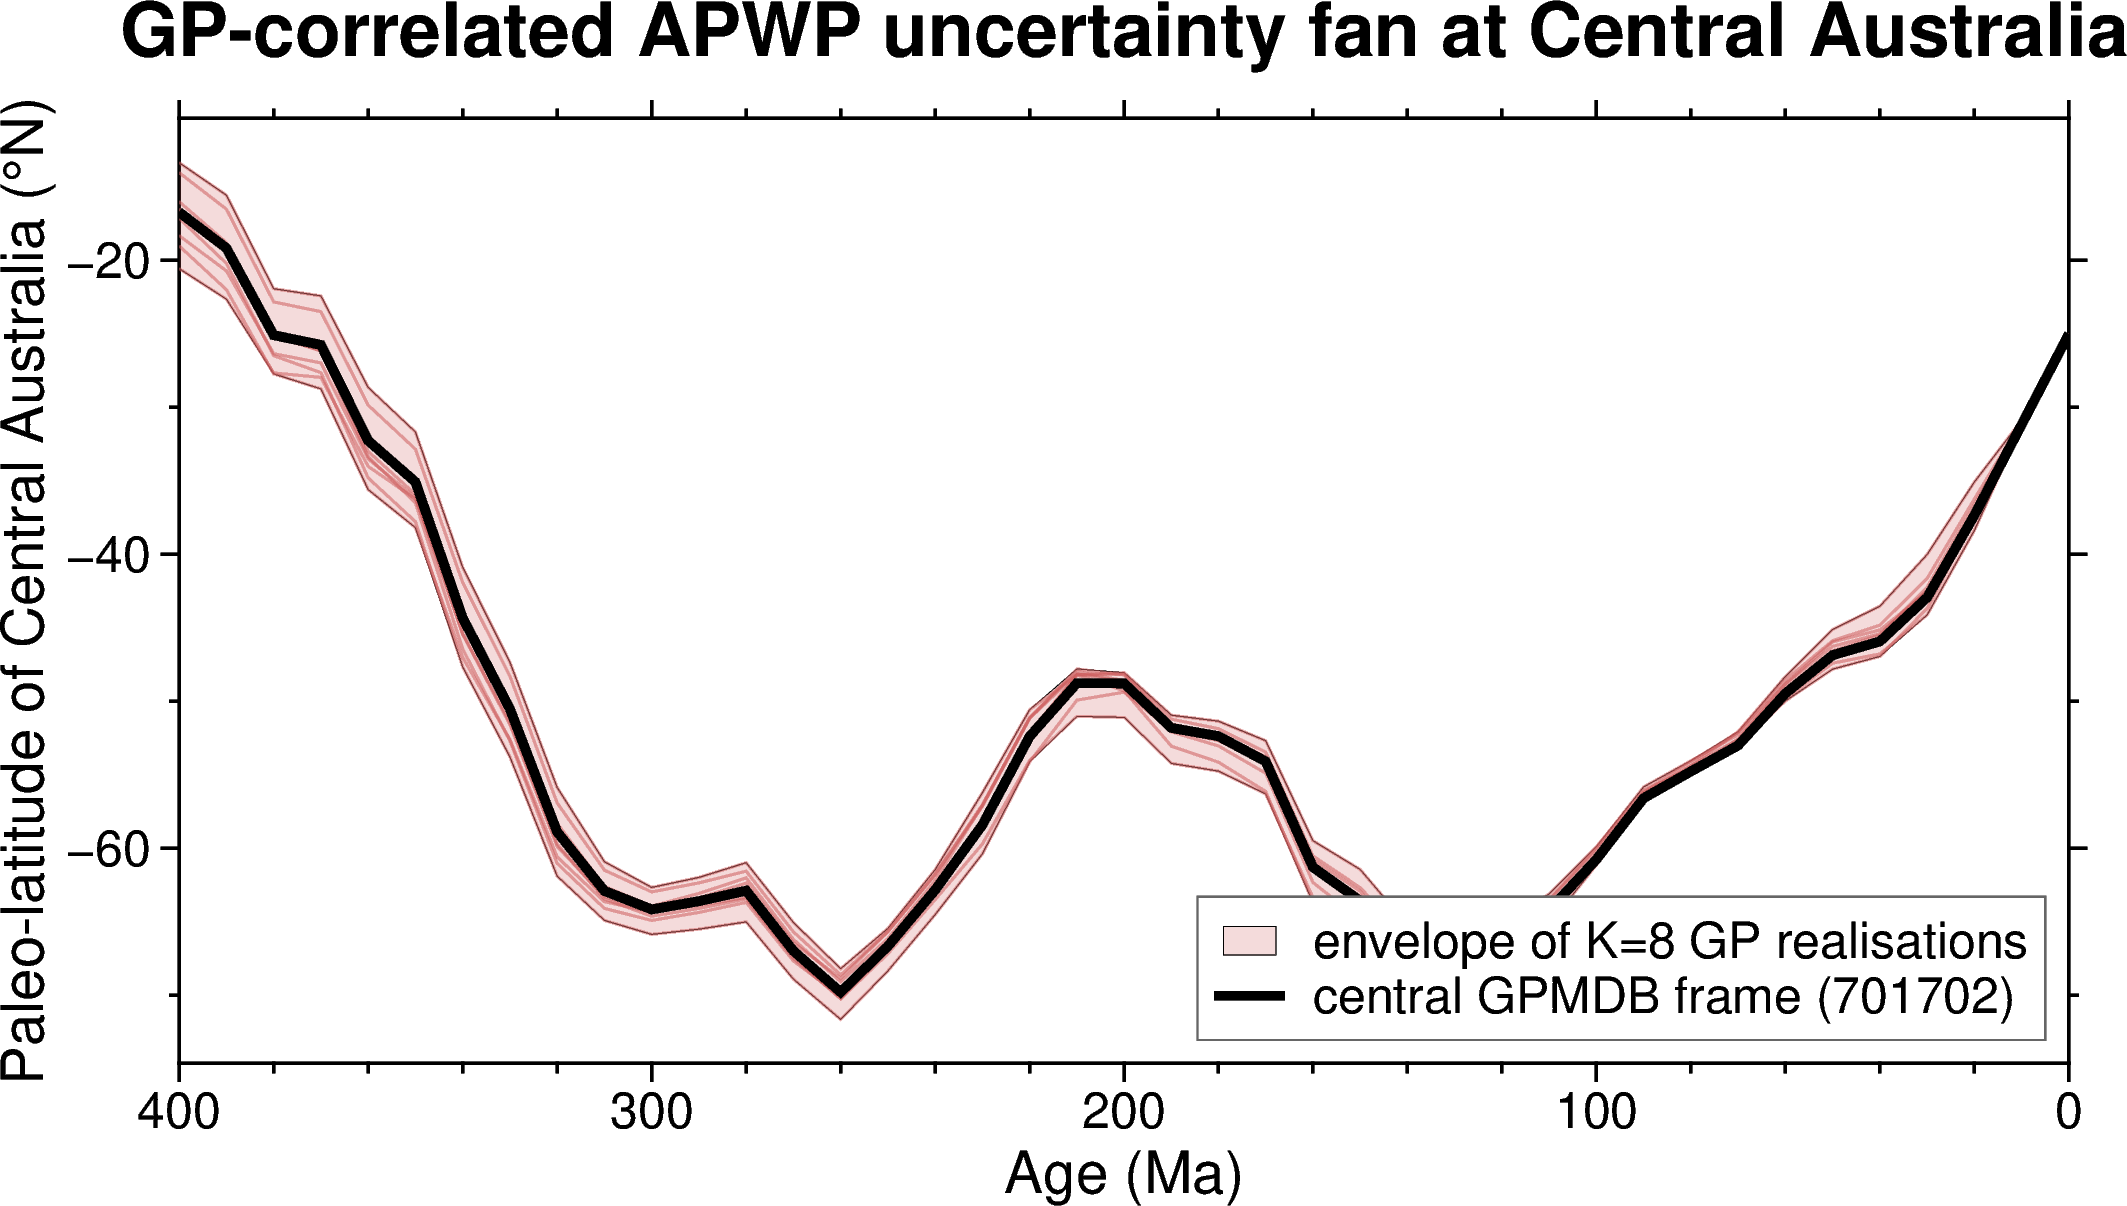

    0 Ma: paleo-latitude envelope width = 0.0°
   50 Ma: paleo-latitude envelope width = 2.7°
  100 Ma: paleo-latitude envelope width = 1.3°
  150 Ma: paleo-latitude envelope width = 4.9°
  200 Ma: paleo-latitude envelope width = 3.0°
  250 Ma: paleo-latitude envelope width = 2.9°
  300 Ma: paleo-latitude envelope width = 3.2°
  350 Ma: paleo-latitude envelope width = 6.5°
  400 Ma: paleo-latitude envelope width = 7.2°


In [9]:
# Cell 8 — paleo-latitude envelope at a reference site (pyGMT)
import math
import numpy as np

# === USER CONFIGURATION =========================================
REF_SITE_NAME  = "Central Australia"
REF_SITE_LON   = 134.0
REF_SITE_LAT   = -25.0
REF_SITE_PLATE = 801             # Australian plate
AGES_FOR_BAND  = np.arange(0, 401, 10)  # Ma, every 10 Myr
# =================================================================

paleolat_traces = {}             # anchor_id -> array of paleolats per age
for anchor_id, label, *_ in ANCHORS:
    _recon = gplately.PlateReconstruction(
        rotation_model=_rot_model_aug,
        topology_features=_topology_features,
        static_polygons=_static_polygons,
        anchor_plate_id=anchor_id,
    )
    _pts = gplately.Points(_recon,
                            [REF_SITE_LON], [REF_SITE_LAT],
                            plate_id=[REF_SITE_PLATE])
    plat_t = []
    for t in AGES_FOR_BAND:
        rlon, rlat = _pts.reconstruct(float(t), return_array=True)
        plat_t.append(float(rlat[0]))
    paleolat_traces[anchor_id] = np.asarray(plat_t)

# Compute envelope (min, max, central) per age across the K realisations
central     = paleolat_traces[701702]
realisations_stack = np.vstack([paleolat_traces[ANCHOR_ID_BASE + k]
                                 for k in range(K_REALISATIONS)])
env_lo  = realisations_stack.min(axis=0)
env_hi  = realisations_stack.max(axis=0)

# --- pyGMT time-series figure ---
_ages = AGES_FOR_BAND.astype(float)
_ymin = float(min(env_lo.min(), central.min())) - 3
_ymax = float(max(env_hi.max(), central.max())) + 3
_xmax = float(_ages.max())

fig = pygmt.Figure()
fig.basemap(region=[0, _xmax, _ymin, _ymax],
            projection="X-16c/8c",
            frame=["WSne+tGP-correlated APWP uncertainty fan at " + REF_SITE_NAME,
                   "xaf+lAge (Ma)",
                   "yaf+lPaleo-latitude of " + REF_SITE_NAME + " (\260N)"])

# Envelope polygon
_x_poly = np.concatenate([_ages, _ages[::-1]])
_y_poly = np.concatenate([env_lo, env_hi[::-1]])
fig.plot(x=_x_poly, y=_y_poly, fill="indianred@78", pen="0p",
         label=f"envelope of K={K_REALISATIONS} GP realisations")

# Individual realisations (thin, transparent)
for k in range(K_REALISATIONS):
    fig.plot(x=_ages, y=realisations_stack[k], pen="0.6p,indianred@45")

# Equator reference
fig.plot(x=[0, _xmax], y=[0, 0], pen="0.6p,gray50,--")

# Central path
fig.plot(x=_ages, y=central, pen="2.2p,black", label="central GPMDB frame (701702)")

fig.legend(position="JBR+jBR+o0.2c", box="+gwhite+p0.4p,gray40")
fig.show(width=900)

from IPython.display import display, HTML
display(HTML('<div style="height:1cm"></div>'))

# Print the band width per epoch
band = env_hi - env_lo
for t, b in zip(AGES_FOR_BAND[::5], band[::5]):
    print(f"  {t:3.0f} Ma: paleo-latitude envelope width = {b:.1f}\260")


### 4.3 APWP spaghetti — central path + K GP-sampled alternatives

The most direct visualisation of what the GP machinery actually produced:
T38-style APWP map with the K alternative paths overlaid as thin
semi-transparent red lines. Each alternative weaves a *smooth* trajectory
through the A95 confidence circles of the central poles — exactly what the
GP correlation guarantees. The width of the red fan at each age shows the
effective per-pole uncertainty; the smoothness of each individual red line
shows that the alternatives respect the physical constraint of continuous
continental motion (no random zigzags between adjacent ages).


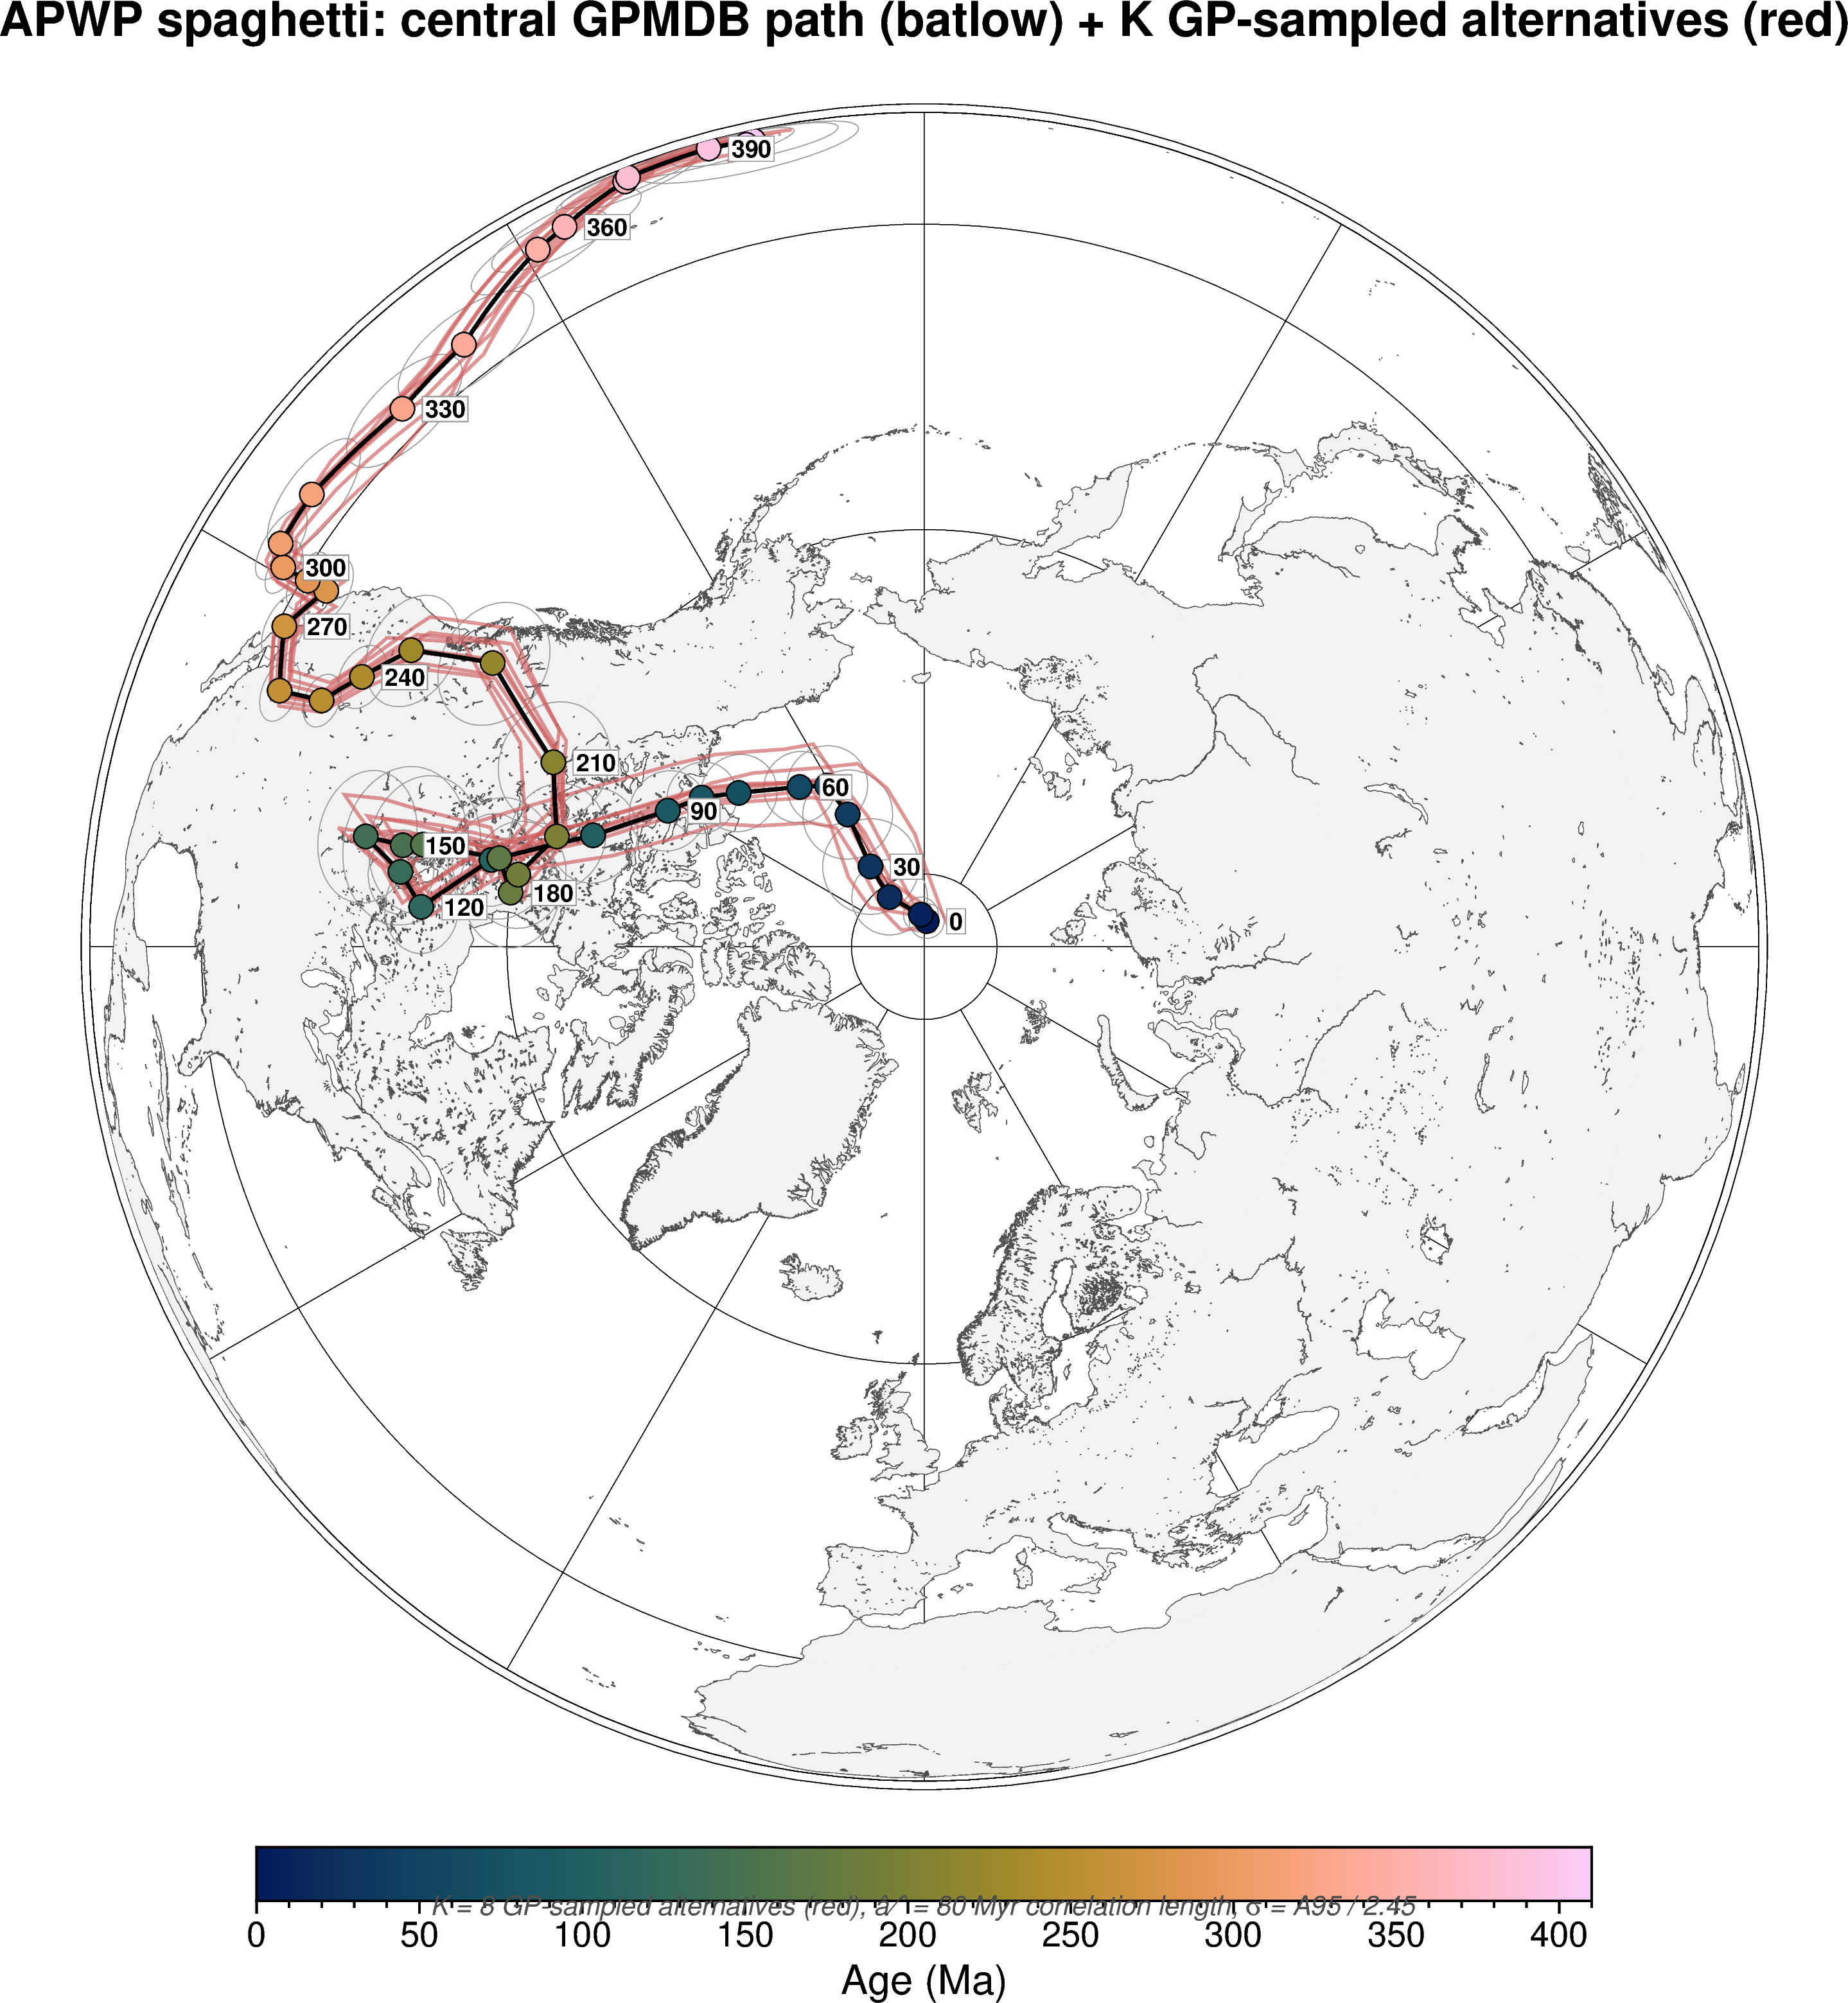

In [10]:
# Cell 9 — APWP spaghetti: central path + K GP-sampled alternatives
import math
import numpy as np

def _small_circle(lat, lon, radius_deg, n=73):
    """Return (lats, lons) tracing a small circle of `radius_deg` around
    (lat, lon). Same recipe as T38 Cell 5."""
    c = np.array([math.cos(math.radians(lat))*math.cos(math.radians(lon)),
                  math.cos(math.radians(lat))*math.sin(math.radians(lon)),
                  math.sin(math.radians(lat))])
    ref = np.array([0, 0, 1.0]) if abs(c[2]) < 0.95 else np.array([1.0, 0, 0])
    u = np.cross(c, ref); u /= np.linalg.norm(u); v = np.cross(c, u)
    t = np.linspace(0, 2*np.pi, n); r = math.radians(radius_deg)
    p = (math.cos(r) * c[:, None]
         + math.sin(r) * (np.cos(t) * u[:, None] + np.sin(t) * v[:, None]))
    return np.degrees(np.arcsin(p[2])), np.degrees(np.arctan2(p[1], p[0]))

fig = pygmt.Figure()
fig.basemap(region="g", projection="G0/90/22c",
            frame=["g30",
                   "+tAPWP spaghetti: central GPMDB path (batlow) + K GP-sampled alternatives (red)"])
fig.coast(land="gray95", shorelines="0.2p,gray30", resolution="i", area_thresh=10)

# 1. A95 circles around the central poles — light grey
for _, r in central_apwp.iterrows():
    if np.isfinite(r.a95) and r.a95 < 60:
        cl, cn = _small_circle(float(r.plat), float(r.plon), float(r.a95))
        fig.plot(x=cn, y=cl, pen="0.25p,gray60")

# 2. K alternative APWPs — thin semi-transparent red lines
for k, df in enumerate(realisations):
    fig.plot(x=df.plon.values.astype(float),
             y=df.plat.values.astype(float),
             pen="1.2p,indianred", transparency=35)

# 3. Central APWP — thick batlow-coloured path, age-coloured circles, labels
pygmt.makecpt(cmap="batlow", series=[0, float(central_apwp.age.max())])
fig.plot(x=central_apwp.plon.values.astype(float),
         y=central_apwp.plat.values.astype(float),
         pen="1.5p,black")
fig.plot(x=central_apwp.plon.values.astype(float),
         y=central_apwp.plat.values.astype(float),
         style="c0.32c",
         fill=central_apwp.age.values.astype(float),
         cmap=True, pen="0.4p,black")
# Age labels every 3rd pole
for _, r in central_apwp.iloc[::3].iterrows():
    fig.text(x=float(r.plon), y=float(r.plat),
             text=f"{r.age:.0f}",
             offset="0.3c/0c", justify="LM",
             font="9p,Helvetica-Bold,black",
             fill="white", pen="0.3p,gray60")
fig.colorbar(frame="af+lAge (Ma)")
fig.text(text=f"K = {K_REALISATIONS} GP-sampled alternatives (red), "
              f"ℓ = {LENGTH_SCALE_MYR:.0f} Myr correlation length, "
              f"σ = A95 / 2.45",
         position="BC", offset="0c/-1.5c", justify="TC", no_clip=True,
         font="10p,Helvetica-Oblique,gray30")
fig.show(width=900)
from IPython.display import display, HTML
display(HTML('<div style="height:1cm"></div>'))


## Extend this

- Add a third frame: rebuild T38 with `Q_MIN = 2` or `4`, embed it as `701703`, and overlay it in a second line colour.
- Plot the great-circle distance between the two frames' reconstructed Africa through time — where does the divergence peak, and does it coincide with sparse intervals in the T38 APWP?
- Mask the comparison to times where the T38 APWP has A95 < 10° to see only the well-constrained signal.
- Swap the coastlines for continental polygons, or add the plate-boundary backbone (see T01) to the base frame only.


## References

- Torsvik, T.H. et al. (2012). Phanerozoic polar wander, palaeogeography and dynamics. *Earth-Science Reviews* 114, 325–368.
- Doubrovine, P.V. et al. (2012). Absolute plate motions in a reference frame defined by moving hotspots. *J. Geophys. Res.* 117, B09101.
- Mather, B.R. et al. (2024). GPlately. *Geoscience Data Journal* 11, 3–10.
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515

- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Fox, P. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9(2), 371-383. https://doi.org/10.1002/gdj3.146
